In [42]:
# STREAMLINED NEURON + ASTROCYTE TRIAL ANALYSIS
# Publication-style notebook
# Rebecca Suthard
# ============================================================

from pathlib import Path
import inspect
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.signal import savgol_filter

from rastermap import Rastermap

In [43]:
# GLOBAL STYLE
# ============================================================

sns.set_style("ticks")

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 8,
    "axes.titlesize": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 2.5,
    "ytick.major.size": 2.5,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# Consistent colors
NEURON_RED = "#C62828"
NEURON_RED_LIGHT = "#EF9A9A"
NEURON_RED_MID = "#E57373"

ASTRO_GREEN = "#2E7D32"
ASTRO_GREEN_LIGHT = "#A5D6A7"
ASTRO_GREEN_MID = "#66BB6A"

BLACK = "#222222"
GRAY = "#777777"

In [44]:
# PATHS / CONFIG
# ============================================================

base_dir = Path("/Users/suthardr/Desktop/621N_FC")

output_root = base_dir / "analysis_outputs_streamlined"
output_dirs = {
    "trial_average": output_root / "01_trial_average",
    "epoch_quantification": output_root / "02_epoch_quantification",
    "trial_by_trial": output_root / "03_trial_by_trial",
    "shock_aligned": output_root / "04_shock_aligned",
    "tables": output_root / "05_tables",
}

for folder in output_dirs.values():
    folder.mkdir(parents=True, exist_ok=True)

print("Saving outputs to:")
for name, folder in output_dirs.items():
    print(f"  {name}: {folder}")

# Acquisition
total_hz = 20.4
per_channel_hz = total_hz / 2  # 10.2 Hz per color channel

# Trial structure
CS_START = 0
TRACE_START = 20
US_START = 40
TRIAL_WINDOW = 50  # only 10 sec after US

DATASETS = {
    "neurons": {
        "s2p_dir": base_dir / "suite2p_red/plane0/",
        "signal_type": "spks",
        "shock_frames": np.array([2179, 4365, 6550, 8735, 10925]),
        "cmap": "Reds",
        "main_color": NEURON_RED,
        "epoch_colors": {
            "CS+": NEURON_RED_LIGHT,
            "Trace": NEURON_RED_MID,
            "US": NEURON_RED,
        },
        "ylabel": "Neuron #",
        "label": "Neurons",
    },
    "astrocytes": {
        "s2p_dir": base_dir / "suite2p/plane0/",
        "signal_type": "dff",
        "shock_frames": np.array([2185, 4375, 6560, 8740, 10930]),
        "cmap": "Greens",
        "main_color": ASTRO_GREEN,
        "epoch_colors": {
            "CS+": ASTRO_GREEN_LIGHT,
            "Trace": ASTRO_GREEN_MID,
            "US": ASTRO_GREEN,
        },
        "ylabel": "Astrocyte #",
        "label": "Astrocytes",
    }
}

Saving outputs to:
  trial_average: /Users/suthardr/Desktop/621N_FC/analysis_outputs_streamlined/01_trial_average
  epoch_quantification: /Users/suthardr/Desktop/621N_FC/analysis_outputs_streamlined/02_epoch_quantification
  trial_by_trial: /Users/suthardr/Desktop/621N_FC/analysis_outputs_streamlined/03_trial_by_trial
  shock_aligned: /Users/suthardr/Desktop/621N_FC/analysis_outputs_streamlined/04_shock_aligned
  tables: /Users/suthardr/Desktop/621N_FC/analysis_outputs_streamlined/05_tables


In [45]:
# HELPER FUNCTIONS
# ============================================================

def save_figure(fig, out_path_base, dpi=600):
    """
    Save both SVG and PNG.
    out_path_base should be a Path WITHOUT extension.
    """
    fig.savefig(str(out_path_base) + ".svg", dpi=dpi, bbox_inches="tight")
    fig.savefig(str(out_path_base) + ".png", dpi=dpi, bbox_inches="tight")


def ensure_cells_x_time(traces, timestamps):
    """
    Ensure array is cells x time.
    """
    return traces.T if traces.shape[0] == len(timestamps) else traces


def sec_to_idx(t_rel, sec):
    return np.argmin(np.abs(t_rel - sec))


def add_trial_epoch_lines(ax, t_rel, color="white", lw=0.75):
    ax.axvline(sec_to_idx(t_rel, 0), color=color, linestyle="--", lw=lw)
    ax.axvline(sec_to_idx(t_rel, 20), color=color, linestyle="--", lw=lw)
    ax.axvline(sec_to_idx(t_rel, 40), color=color, linestyle="--", lw=lw)


def style_axis(ax):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)
        spine.set_color("black")
    ax.tick_params(width=0.8, length=2.5)


def make_rastermap(**prefs):
    """
    Compatibility wrapper across Rastermap versions.
    """
    sig = inspect.signature(Rastermap)
    have = set(sig.parameters.keys())

    if {"n_clusters", "n_PCs", "locality", "time_lag_window"}.issubset(have):
        kwargs = dict(
            n_clusters=50,
            n_PCs=50,
            locality=0.5,
            time_lag_window=0,
            grid_upsample=10
        )
    elif {"n_X", "alpha", "n_PCs"}.issubset(have):
        kwargs = dict(
            n_X=50,
            alpha=1.0,
            n_PCs=50,
            timelag=0
        )
    elif {"n_components", "n_neighbors", "n_pcs"}.issubset(have):
        kwargs = dict(
            n_components=1,
            n_neighbors=50,
            n_pcs=50,
            n_epochs=500,
            learning_rate=1.0,
            random_state=0
        )
    else:
        kwargs = {}

    kwargs.update(prefs)
    return Rastermap(**kwargs)

In [46]:
# LOADING FUNCTIONS
# ============================================================

def load_suite2p_dataset(dataset_name, cfg, per_channel_hz=10.2):
    """
    Load either neuron spks or astrocyte dFF.

    Returns dict with:
        traces: cells x time
        time: seconds
        shock_times, tone_times, trace_times
    """
    s2p_dir = cfg["s2p_dir"]

    iscell = np.load(s2p_dir / "iscell.npy", allow_pickle=True)
    cell_mask = iscell[:, 0].astype(bool)

    if cfg["signal_type"] == "spks":
        spks = np.load(s2p_dir / "spks.npy")
        traces = spks[cell_mask, :]

    elif cfg["signal_type"] == "dff":
        F = np.load(s2p_dir / "F.npy")
        Fneu = np.load(s2p_dir / "Fneu.npy")

        F_cells = F[cell_mask, :]
        Fneu_cells = Fneu[cell_mask, :]

        # Neuropil correction
        Fcorr = F_cells - 0.7 * Fneu_cells

        # Baseline
        window_length = 501
        if window_length >= Fcorr.shape[1]:
            window_length = Fcorr.shape[1] - 1
        if window_length % 2 == 0:
            window_length -= 1

        baseline = savgol_filter(
            Fcorr,
            window_length=window_length,
            polyorder=3,
            axis=1
        )
        baseline[baseline == 0] = np.nan

        traces = (Fcorr - baseline) / baseline
        traces = np.nan_to_num(traces, nan=0.0, posinf=0.0, neginf=0.0)

    else:
        raise ValueError("signal_type must be 'spks' or 'dff'")

    time = np.arange(traces.shape[1]) / per_channel_hz

    shock_times = cfg["shock_frames"] / per_channel_hz
    tone_times = shock_times - 40
    trace_times = shock_times - 20

    print(f"\nLoaded {dataset_name}")
    print("  traces shape:", traces.shape)
    print("  recording duration (min):", np.round(time[-1] / 60, 2))
    print("  tone times:", np.round(tone_times, 2))
    print("  shock times:", np.round(shock_times, 2))

    return {
        "traces": traces,
        "time": time,
        "shock_times": shock_times,
        "tone_times": tone_times,
        "trace_times": trace_times,
    }

In [47]:
# TRIAL EXTRACTION
# ============================================================

def extract_trials(traces, timestamps, tone_events, trial_window=50, zscore=True):
    """
    Returns:
        trial_data: cells x trials x timepoints
        t_rel: time from CS+ onset
    """
    timestamps = np.asarray(timestamps, dtype=float)
    tone_events = np.asarray(tone_events, dtype=float)

    data = ensure_cells_x_time(traces, timestamps)

    fs = 1.0 / np.median(np.diff(timestamps))
    n_points = int(np.round(trial_window * fs))
    t_rel = np.arange(n_points) / fs

    all_cells = []

    for sig in data:
        chunks = []

        for tone in tone_events:
            t_win = tone + t_rel

            if t_win[0] < timestamps[0] or t_win[-1] > timestamps[-1]:
                continue

            chunk = np.interp(t_win, timestamps, sig)
            chunks.append(chunk)

        if len(chunks) == 0:
            all_cells.append(np.full((len(tone_events), n_points), np.nan))
            continue

        chunks = np.vstack(chunks)

        if zscore:
            m = np.nanmean(chunks)
            s = np.nanstd(chunks)
            if s == 0 or np.isnan(s):
                s = 1
            chunks = (chunks - m) / s

        all_cells.append(chunks)

    trial_data = np.stack(all_cells, axis=0)
    return trial_data, t_rel

In [48]:
# METRIC EXTRACTION
# ============================================================

def make_epoch_response_df(avg_trial_by_cell, t_rel):
    """
    Per-cell epoch responses from trial-averaged activity.
    """
    cs_idx0 = sec_to_idx(t_rel, 0)
    cs_idx1 = sec_to_idx(t_rel, 20)

    trace_idx0 = sec_to_idx(t_rel, 20)
    trace_idx1 = sec_to_idx(t_rel, 40)

    us_idx0 = sec_to_idx(t_rel, 40)
    us_idx1 = sec_to_idx(t_rel, 50)

    cs_mean = np.nanmean(avg_trial_by_cell[:, cs_idx0:cs_idx1], axis=1)
    trace_mean = np.nanmean(avg_trial_by_cell[:, trace_idx0:trace_idx1], axis=1)
    us_mean = np.nanmean(avg_trial_by_cell[:, us_idx0:us_idx1], axis=1)
    us_max = np.nanmax(avg_trial_by_cell[:, us_idx0:us_idx1], axis=1)

    response_df = pd.DataFrame({
        "cell": np.arange(avg_trial_by_cell.shape[0]),
        "CS+": cs_mean,
        "Trace": trace_mean,
        "US": us_mean,
        "US_max": us_max,
    })

    return response_df


def make_trialwise_population_df(trial_data, t_rel):
    """
    Population mean response across trials for each epoch.
    Returns long-format DataFrame.
    """
    n_cells, n_trials, _ = trial_data.shape

    cs_idx0 = sec_to_idx(t_rel, 0)
    cs_idx1 = sec_to_idx(t_rel, 20)

    trace_idx0 = sec_to_idx(t_rel, 20)
    trace_idx1 = sec_to_idx(t_rel, 40)

    us_idx0 = sec_to_idx(t_rel, 40)
    us_idx1 = sec_to_idx(t_rel, 50)

    cs_by_trial = np.nanmean(trial_data[:, :, cs_idx0:cs_idx1], axis=(0, 2))
    trace_by_trial = np.nanmean(trial_data[:, :, trace_idx0:trace_idx1], axis=(0, 2))
    us_by_trial = np.nanmean(trial_data[:, :, us_idx0:us_idx1], axis=(0, 2))

    df = pd.DataFrame({
        "trial": np.arange(1, n_trials + 1),
        "CS+": cs_by_trial,
        "Trace": trace_by_trial,
        "US": us_by_trial,
    })

    return df

In [49]:
# RASTERMAP
# ============================================================

def run_rastermap_on_trials(trial_data):
    """
    Fit Rastermap on concatenated trial-by-trial activity.

    Returns:
        raster_order: original cell indices in Rastermap order
        data_concat_sorted: sorted concatenated trial matrix
        valid_cells: boolean mask on original cells
    """
    n_cells, n_trials, n_time = trial_data.shape
    data_concat = trial_data.reshape(n_cells, n_trials * n_time)

    valid_cells = (
            np.isfinite(data_concat).all(axis=1) &
            (np.nanstd(data_concat, axis=1) > 0)
    )

    data_valid = data_concat[valid_cells]
    data_valid_z = stats.zscore(data_valid, axis=1, nan_policy="omit")
    data_valid_z = np.nan_to_num(data_valid_z, nan=0.0)

    rm = make_rastermap()
    rm.fit(data_valid_z)

    embedding = rm.embedding
    if embedding.ndim == 2:
        order_valid = np.argsort(embedding[:, 0])
    else:
        order_valid = np.argsort(embedding)

    original_valid_cell_ids = np.where(valid_cells)[0]
    raster_order = original_valid_cell_ids[order_valid]

    data_concat_sorted = data_concat[raster_order, :]

    return raster_order, data_concat_sorted, valid_cells

In [50]:
# SHOCK-ALIGNED MATRIX
# ============================================================

def make_shock_aligned_matrix(traces, timestamps, shock_times, window=10, sort_by="peak_time"):
    """
    Build shock-aligned mean response matrix and sort it.

    Returns:
        z_plot: sorted heatmap matrix
        sort_idx: row order in original cell coordinates
        z_unsorted: unsorted z-scored matrix
        t_rel_event: event-aligned time vector
    """
    timestamps = np.asarray(timestamps, dtype=float)
    shock_times = np.asarray(shock_times, dtype=float)

    data = ensure_cells_x_time(traces, timestamps)

    fs = 1.0 / np.median(np.diff(timestamps))
    n_points = int(np.round(window * fs))
    t_rel_event = np.arange(n_points) / fs

    all_cells = []

    for sig in data:
        chunks = []

        for event in shock_times:
            t_win = event + t_rel_event

            if t_win[0] < timestamps[0] or t_win[-1] > timestamps[-1]:
                continue

            chunk = np.interp(t_win, timestamps, sig)
            chunks.append(chunk)

        if len(chunks) == 0:
            all_cells.append(np.full(n_points, np.nan))
            continue

        all_cells.append(np.nanmean(chunks, axis=0))

    eta_mean = np.vstack(all_cells)

    z_unsorted = stats.zscore(eta_mean, axis=1, nan_policy="omit")
    z_unsorted = np.nan_to_num(z_unsorted, nan=0.0)

    if sort_by == "peak_time":
        sort_idx = np.argsort(np.argmax(z_unsorted, axis=1))
    elif sort_by == "max":
        sort_idx = np.argsort(np.nanmax(z_unsorted, axis=1))[::-1]
    else:
        sort_idx = np.arange(z_unsorted.shape[0])

    z_plot = z_unsorted[sort_idx]

    return z_plot, sort_idx, z_unsorted, t_rel_event

In [51]:
# PLOTTING FUNCTIONS
# ============================================================

def plot_trial_average_heatmap(result, cfg, save_base=None):
    data_plot = result["avg_trial_by_cell"][result["raster_order"], :]
    t_rel = result["t_rel"]

    vmin, vmax = np.nanpercentile(data_plot, [1, 99])

    fig, ax = plt.subplots(figsize=(2.7, 2.15), dpi=600)

    sns.heatmap(
        data_plot,
        ax=ax,
        cmap=cfg["cmap"],
        vmin=vmin,
        vmax=vmax,
        cbar=True,
        cbar_kws={
            "label": "Z-score",
            "fraction": 0.055,
            "pad": 0.04
        },
        xticklabels=False,
        yticklabels=False,
        rasterized=True
    )

    add_trial_epoch_lines(ax, t_rel, color="white", lw=0.75)

    ax.set_xticks([sec_to_idx(t_rel, 0), sec_to_idx(t_rel, 20), sec_to_idx(t_rel, 40)])
    ax.set_xticklabels(["CS+", "Trace", "US"], rotation=0)

    ticklabels = ax.get_xticklabels()
    ticklabels[0].set_color(cfg["epoch_colors"]["CS+"])
    ticklabels[0].set_fontweight("bold")
    ticklabels[1].set_color(BLACK)
    ticklabels[2].set_color(cfg["epoch_colors"]["US"])
    ticklabels[2].set_fontweight("bold")

    n_cells = data_plot.shape[0]
    ax.set_yticks([0.5, n_cells - 0.5])
    ax.set_yticklabels(["1", str(n_cells)], rotation=0)

    ax.set_xlabel("")
    ax.set_ylabel(cfg["ylabel"])
    ax.set_title(f"{cfg['label']}\nTrial average", pad=4)

    style_axis(ax)

    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=7, width=0.8, length=2)
    cbar.set_label("Z-score", fontsize=8)

    plt.tight_layout()

    if save_base is not None:
        save_figure(fig, save_base, dpi=600)

    plt.show()


def plot_epoch_quantification(result, cfg, save_base=None):
    response_df = result["response_df"]

    long_df = response_df.melt(
        id_vars="cell",
        value_vars=["CS+", "Trace", "US"],
        var_name="Epoch",
        value_name="Response"
    )

    fig, ax = plt.subplots(figsize=(2.75, 2.2), dpi=600)

    sns.boxplot(
        data=long_df,
        x="Epoch",
        y="Response",
        order=["CS+", "Trace", "US"],
        color=cfg["main_color"],
        width=0.5,
        fliersize=0,
        linewidth=0.8,
        ax=ax
    )

    sns.stripplot(
        data=long_df,
        x="Epoch",
        y="Response",
        order=["CS+", "Trace", "US"],
        color="black",
        alpha=0.25,
        size=1.8,
        jitter=0.22,
        ax=ax
    )

    ax.axhline(0, color=GRAY, linestyle="--", lw=0.8)
    ax.set_xlabel("")
    ax.set_ylabel("Mean response (z-score)")
    ax.set_title(f"{cfg['label']}\nEpoch responses", pad=4)

    for label, epoch in zip(ax.get_xticklabels(), ["CS+", "Trace", "US"]):
        if epoch == "CS+":
            label.set_color(cfg["epoch_colors"]["CS+"])
            label.set_fontweight("bold")
        elif epoch == "US":
            label.set_color(cfg["epoch_colors"]["US"])
            label.set_fontweight("bold")
        else:
            label.set_color(BLACK)

    sns.despine(ax=ax)
    style_axis(ax)

    plt.tight_layout()

    if save_base is not None:
        save_figure(fig, save_base, dpi=600)

    plt.show()


def plot_trial_by_trial_rastermap(result, cfg, save_base=None):
    trial_data = result["trial_data"]
    t_rel = result["t_rel"]
    raster_order = result["raster_order"]

    n_cells, n_trials, n_time = trial_data.shape
    data_concat = trial_data.reshape(n_cells, n_trials * n_time)
    data_plot = data_concat[raster_order, :]

    vmin, vmax = np.nanpercentile(data_plot, [1, 99])

    fig, ax = plt.subplots(figsize=(6.8, 3.2), dpi=400)

    im = ax.imshow(
        data_plot,
        aspect="auto",
        cmap=cfg["cmap"],
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest"
    )

    cs_idx = sec_to_idx(t_rel, 0)
    trace_idx = sec_to_idx(t_rel, 20)
    us_idx = sec_to_idx(t_rel, 40)

    for tr in range(n_trials + 1):
        ax.axvline(tr * n_time, color="black", lw=0.45)

    for tr in range(n_trials):
        start = tr * n_time
        ax.axvline(start + cs_idx, color=cfg["epoch_colors"]["CS+"], linestyle="--", lw=0.7)
        ax.axvline(start + trace_idx, color=BLACK, linestyle="--", lw=0.7)
        ax.axvline(start + us_idx, color=cfg["epoch_colors"]["US"], linestyle="--", lw=0.7)

    ax.set_xlabel("Concatenated trials")
    ax.set_ylabel(f"{cfg['label']}, Rastermap order")
    ax.set_title(f"{cfg['label']}\nTrial-by-trial activity", pad=4)

    cbar = plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
    cbar.set_label("Z-score")
    cbar.ax.tick_params(labelsize=7, width=0.8, length=2)

    style_axis(ax)
    plt.tight_layout()

    if save_base is not None:
        save_figure(fig, save_base, dpi=400)

    plt.show()


def plot_response_across_trials(result, cfg, save_base=None):
    df = result["trialwise_population_df"]

    fig, ax = plt.subplots(figsize=(2.95, 2.2), dpi=600)

    ax.plot(df["trial"], df["CS+"], marker="o", ms=3, lw=1.25,
            color=cfg["epoch_colors"]["CS+"], label="CS+")
    ax.plot(df["trial"], df["Trace"], marker="o", ms=3, lw=1.25,
            color=BLACK, label="Trace")
    ax.plot(df["trial"], df["US"], marker="o", ms=3, lw=1.25,
            color=cfg["epoch_colors"]["US"], label="US")

    ax.axhline(0, color=GRAY, linestyle="--", lw=0.8)
    ax.set_xlabel("Trial")
    ax.set_ylabel("Population mean\n(z-score)")
    ax.set_title(f"{cfg['label']}\nResponse across trials", pad=4)

    ax.legend(frameon=False, loc="best", handlelength=1.2)
    sns.despine(ax=ax)
    style_axis(ax)

    plt.tight_layout()

    if save_base is not None:
        save_figure(fig, save_base, dpi=600)

    plt.show()


def plot_shock_aligned_heatmap(result, cfg, save_base=None):
    z_plot = result["shock_aligned"]["z_plot"]
    t_rel_event = result["shock_aligned"]["t_rel_event"]

    vmin, vmax = np.nanpercentile(z_plot, [1, 99])

    fig, ax = plt.subplots(figsize=(2.2, 2.7), dpi=600)

    sns.heatmap(
        z_plot,
        ax=ax,
        cmap=cfg["cmap"],
        vmin=vmin,
        vmax=vmax,
        cbar=True,
        cbar_kws={
            "label": "Z-score",
            "fraction": 0.06,
            "pad": 0.04
        },
        xticklabels=False,
        yticklabels=False,
        rasterized=True
    )

    xticks_sec = [0, 2, 5, 10]
    xticks_pos = [sec_to_idx(t_rel_event, s) for s in xticks_sec]

    ax.set_xticks(xticks_pos)
    ax.set_xticklabels(xticks_sec, rotation=0)

    n_cells = z_plot.shape[0]
    ax.set_yticks([0.5, n_cells - 0.5])
    ax.set_yticklabels(["1", str(n_cells)], rotation=0)

    ax.set_xlabel("Time after US onset (s)")
    ax.set_ylabel(cfg["ylabel"])
    ax.set_title(f"{cfg['label']}\nShock-aligned", pad=4)

    style_axis(ax)

    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=7, width=0.8, length=2)
    cbar.set_label("Z-score", fontsize=8)

    plt.tight_layout()

    if save_base is not None:
        save_figure(fig, save_base, dpi=600)

    plt.show()

In [52]:
# MAIN PIPELINE
# ============================================================

def run_pipeline(dataset_name, cfg):
    loaded = load_suite2p_dataset(dataset_name, cfg, per_channel_hz=per_channel_hz)

    traces = loaded["traces"]
    time = loaded["time"]
    shock_times = loaded["shock_times"]
    tone_times = loaded["tone_times"]
    trace_times = loaded["trace_times"]

    trial_data, t_rel = extract_trials(
        traces=traces,
        timestamps=time,
        tone_events=tone_times,
        trial_window=TRIAL_WINDOW,
        zscore=True
    )

    avg_trial_by_cell = np.nanmean(trial_data, axis=1)

    response_df = make_epoch_response_df(avg_trial_by_cell, t_rel)
    trialwise_population_df = make_trialwise_population_df(trial_data, t_rel)

    raster_order, data_concat_sorted, valid_cells = run_rastermap_on_trials(trial_data)

    z_plot, shock_sort_idx, z_unsorted, t_rel_event = make_shock_aligned_matrix(
        traces=traces,
        timestamps=time,
        shock_times=shock_times,
        window=10,
        sort_by="peak_time"
    )

    result = {
        "name": dataset_name,
        "traces": traces,
        "time": time,
        "shock_times": shock_times,
        "tone_times": tone_times,
        "trace_times": trace_times,
        "trial_data": trial_data,
        "t_rel": t_rel,
        "avg_trial_by_cell": avg_trial_by_cell,
        "response_df": response_df,
        "trialwise_population_df": trialwise_population_df,
        "raster_order": raster_order,
        "data_concat_sorted": data_concat_sorted,
        "valid_cells": valid_cells,
        "shock_aligned": {
            "z_plot": z_plot,
            "sort_idx": shock_sort_idx,
            "z_unsorted": z_unsorted,
            "t_rel_event": t_rel_event,
        }
    }

    return result

In [53]:
# RUN BOTH DATASETS
# ============================================================

results = {}

for dataset_name, cfg in DATASETS.items():
    results[dataset_name] = run_pipeline(dataset_name, cfg)

    print(f"\nFinished {dataset_name}")
    print("  trial_data:", results[dataset_name]["trial_data"].shape)
    print("  avg_trial_by_cell:", results[dataset_name]["avg_trial_by_cell"].shape)
    print("  raster_order:", results[dataset_name]["raster_order"].shape)


Loaded neurons
  traces shape: (166, 13114)
  recording duration (min): 21.43
  tone times: [ 173.63  387.94  602.16  816.37 1031.08]
  shock times: [ 213.63  427.94  642.16  856.37 1071.08]
2026-05-27 12:26:49,961 [INFO] normalizing data across axis=1
2026-05-27 12:26:49,970 [INFO] projecting out mean along axis=0
2026-05-27 12:26:49,975 [INFO] data normalized, 0.01sec
2026-05-27 12:26:49,976 [INFO] sorting activity: 166 valid samples by 2550 timepoints
2026-05-27 12:26:50,576 [INFO] n_PCs = 50 computed, 0.62sec
2026-05-27 12:26:50,619 [INFO] 49 clusters computed, time 0.66sec
2026-05-27 12:26:51,418 [INFO] clusters sorted, time 1.46sec
2026-05-27 12:26:51,458 [INFO] clusters upsampled, time 1.50sec
2026-05-27 12:26:51,481 [INFO] rastermap complete, time 1.52sec

Finished neurons
  trial_data: (166, 5, 510)
  avg_trial_by_cell: (166, 510)
  raster_order: (166,)

Loaded astrocytes
  traces shape: (40, 13115)
  recording duration (min): 21.43
  tone times: [ 174.22  388.92  603.14  816

/Users/suthardr/Documents/GitHub/CalciumKit/venv/lib/python3.9/site-packages/rastermap/rastermap.py:357: UserWarning: data has <= 50 samples, 

                                going to skip clustering and sort samples
  warnings.warn("""data has <= 50 samples, \n


2026-05-27 12:26:52,794 [INFO] clusters sorted, time 1.12sec
2026-05-27 12:26:52,811 [INFO] clusters upsampled, time 1.13sec
2026-05-27 12:26:52,817 [INFO] rastermap complete, time 1.14sec

Finished astrocytes
  trial_data: (40, 5, 510)
  avg_trial_by_cell: (40, 510)
  raster_order: (40,)


In [54]:
# SAVE TABLES
# ============================================================

for dataset_name, cfg in DATASETS.items():
    results[dataset_name]["response_df"].to_csv(
        output_dirs["tables"] / f"{dataset_name}_epoch_response_table.csv",
        index=False
    )

    results[dataset_name]["trialwise_population_df"].to_csv(
        output_dirs["tables"] / f"{dataset_name}_trialwise_population_table.csv",
        index=False
    )

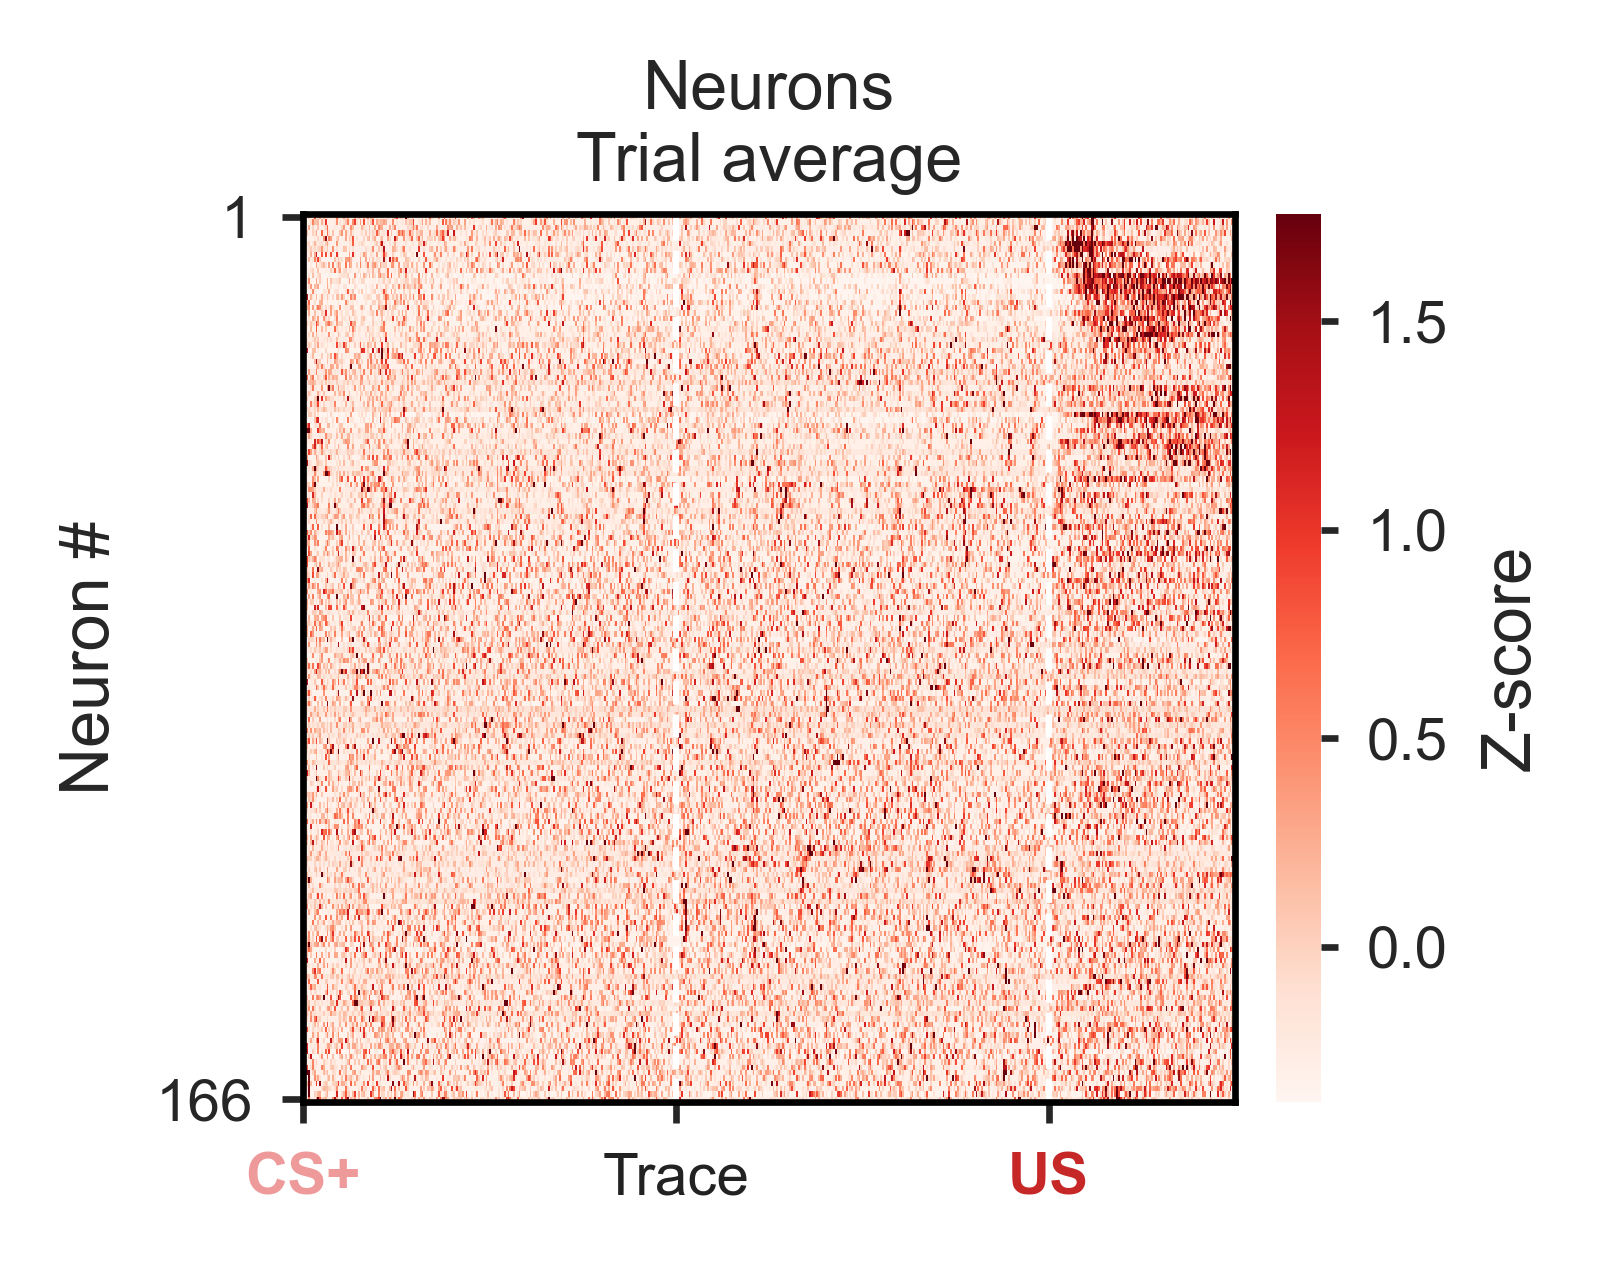

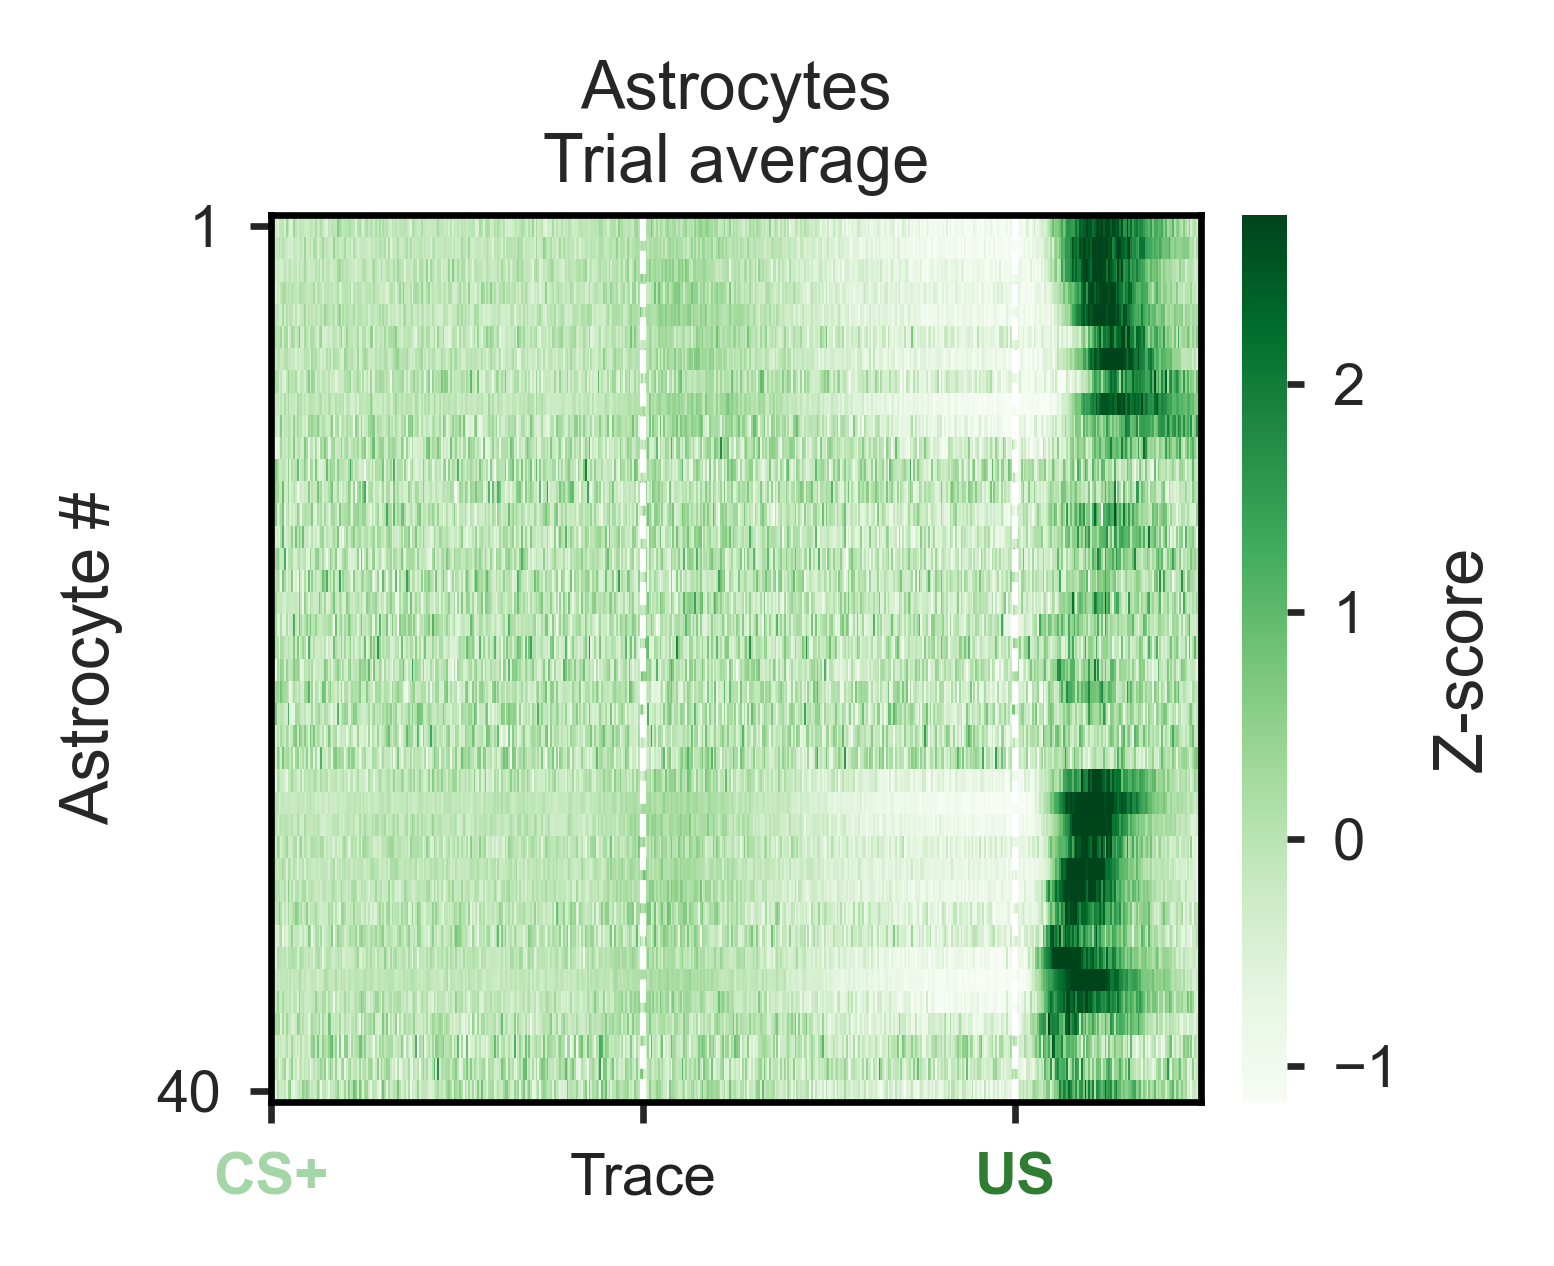

In [55]:
# ESSENTIAL PLOT 1: TRIAL-AVERAGE HEATMAPS
# ============================================================

for dataset_name, cfg in DATASETS.items():
    plot_trial_average_heatmap(
        results[dataset_name],
        cfg,
        save_base=output_dirs["trial_average"] / f"{dataset_name}_trial_average_heatmap"
    )

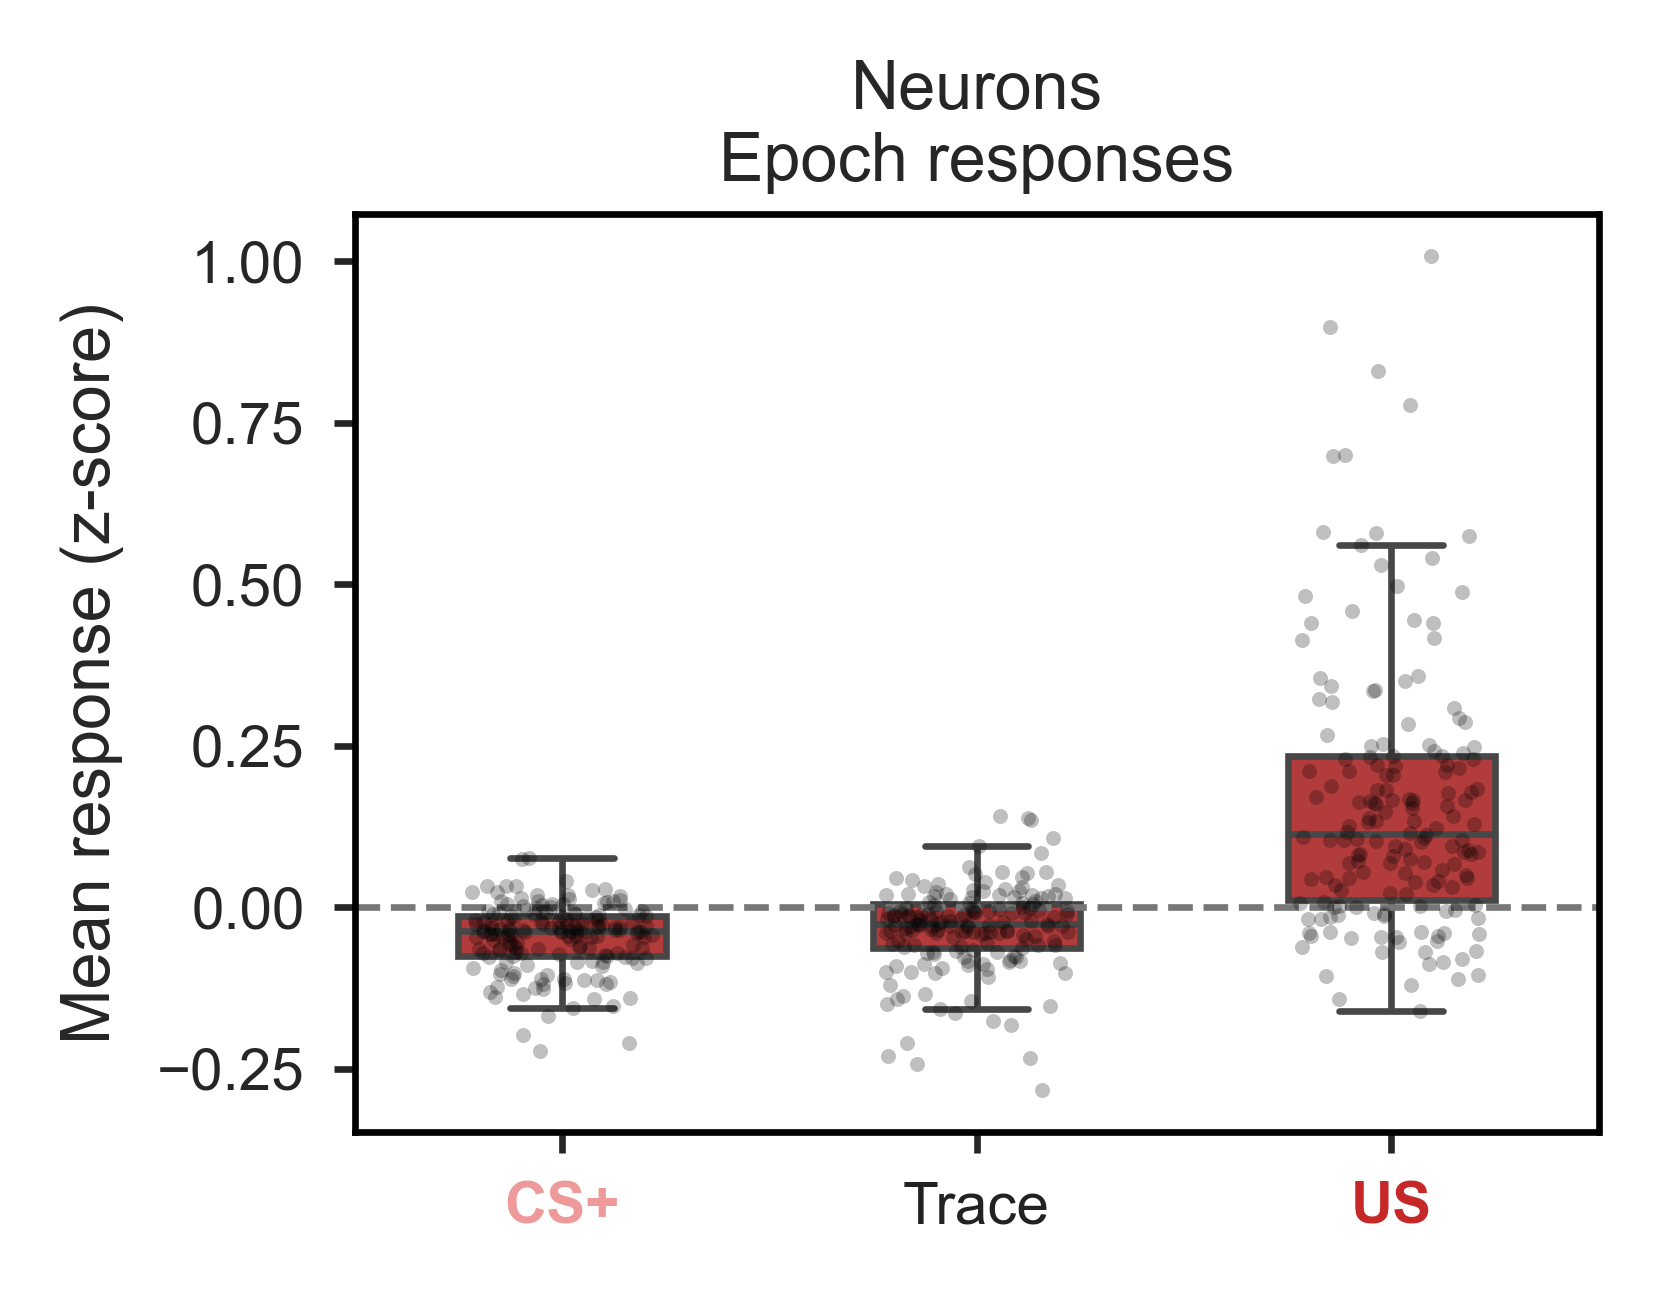

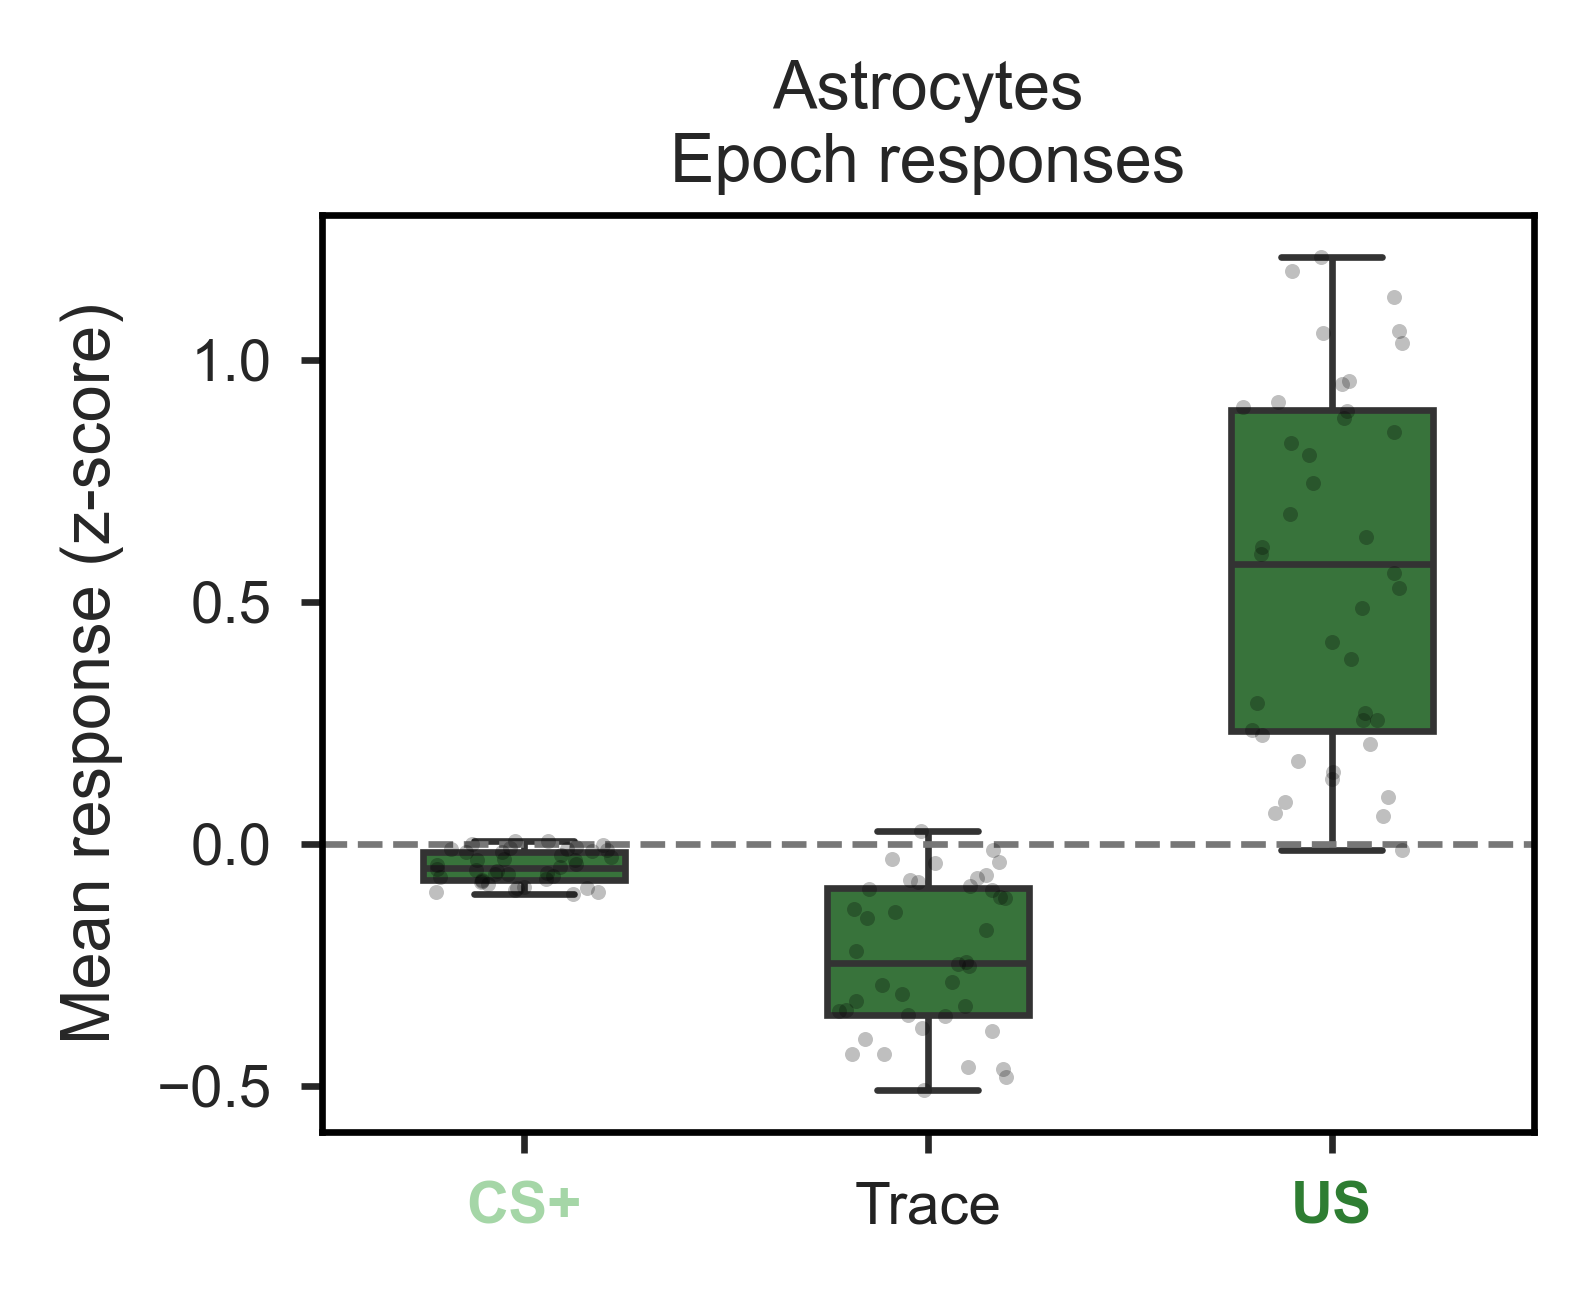

In [56]:
# ESSENTIAL PLOT 2: EPOCH QUANTIFICATION
# ============================================================

for dataset_name, cfg in DATASETS.items():
    plot_epoch_quantification(
        results[dataset_name],
        cfg,
        save_base=output_dirs["epoch_quantification"] / f"{dataset_name}_epoch_quantification"
    )

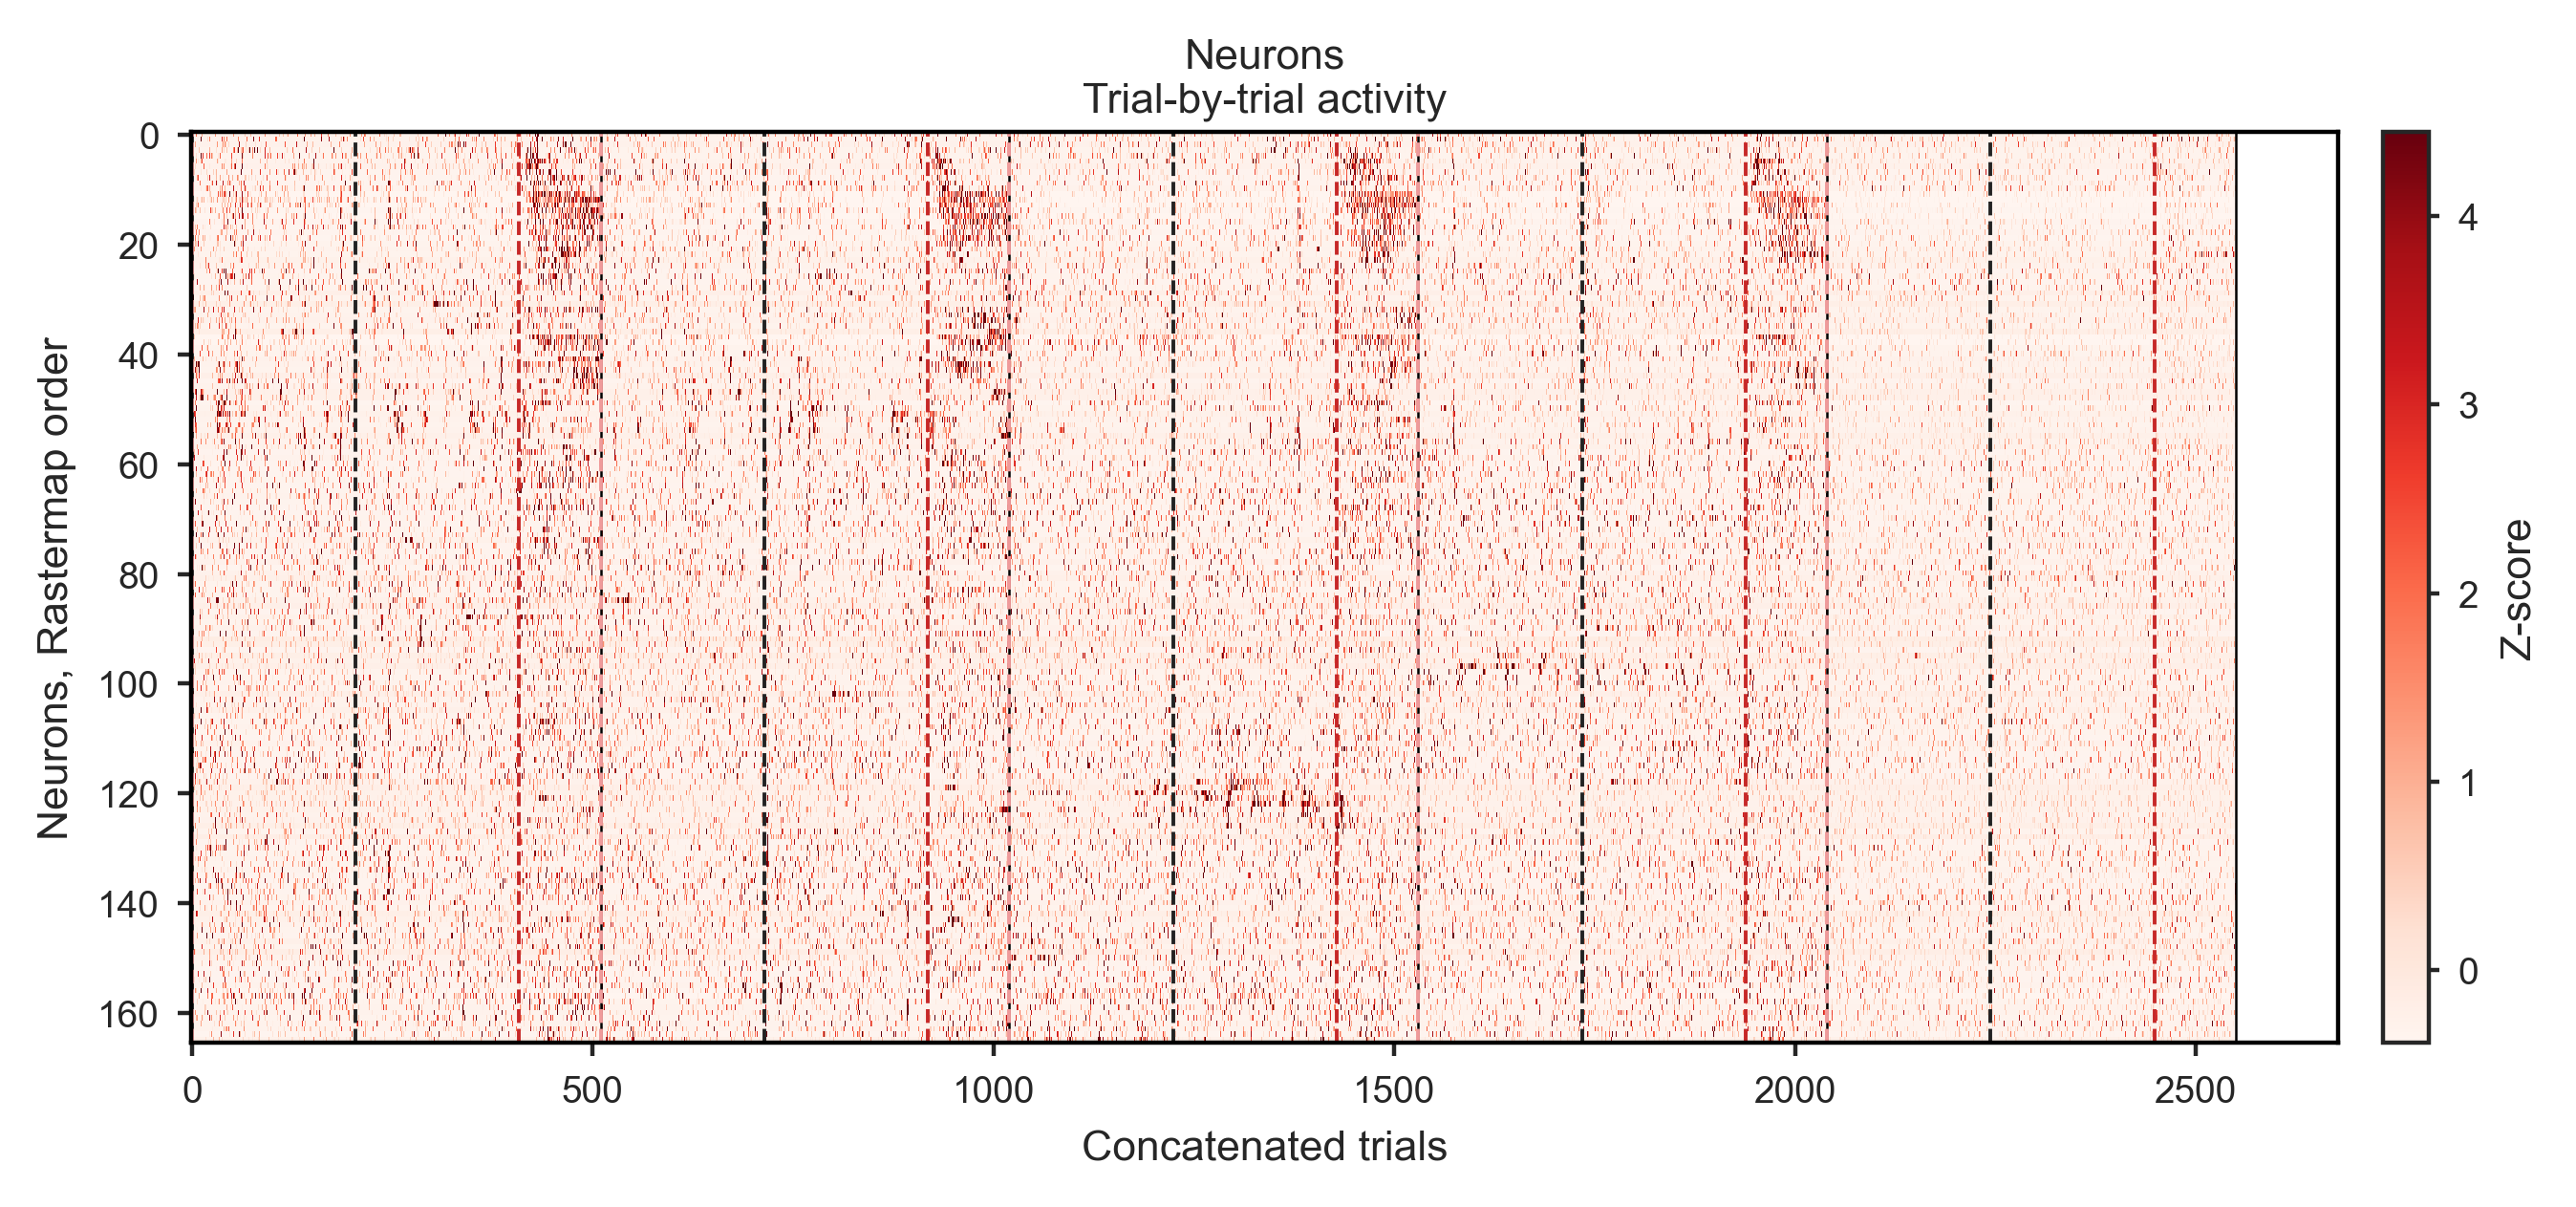

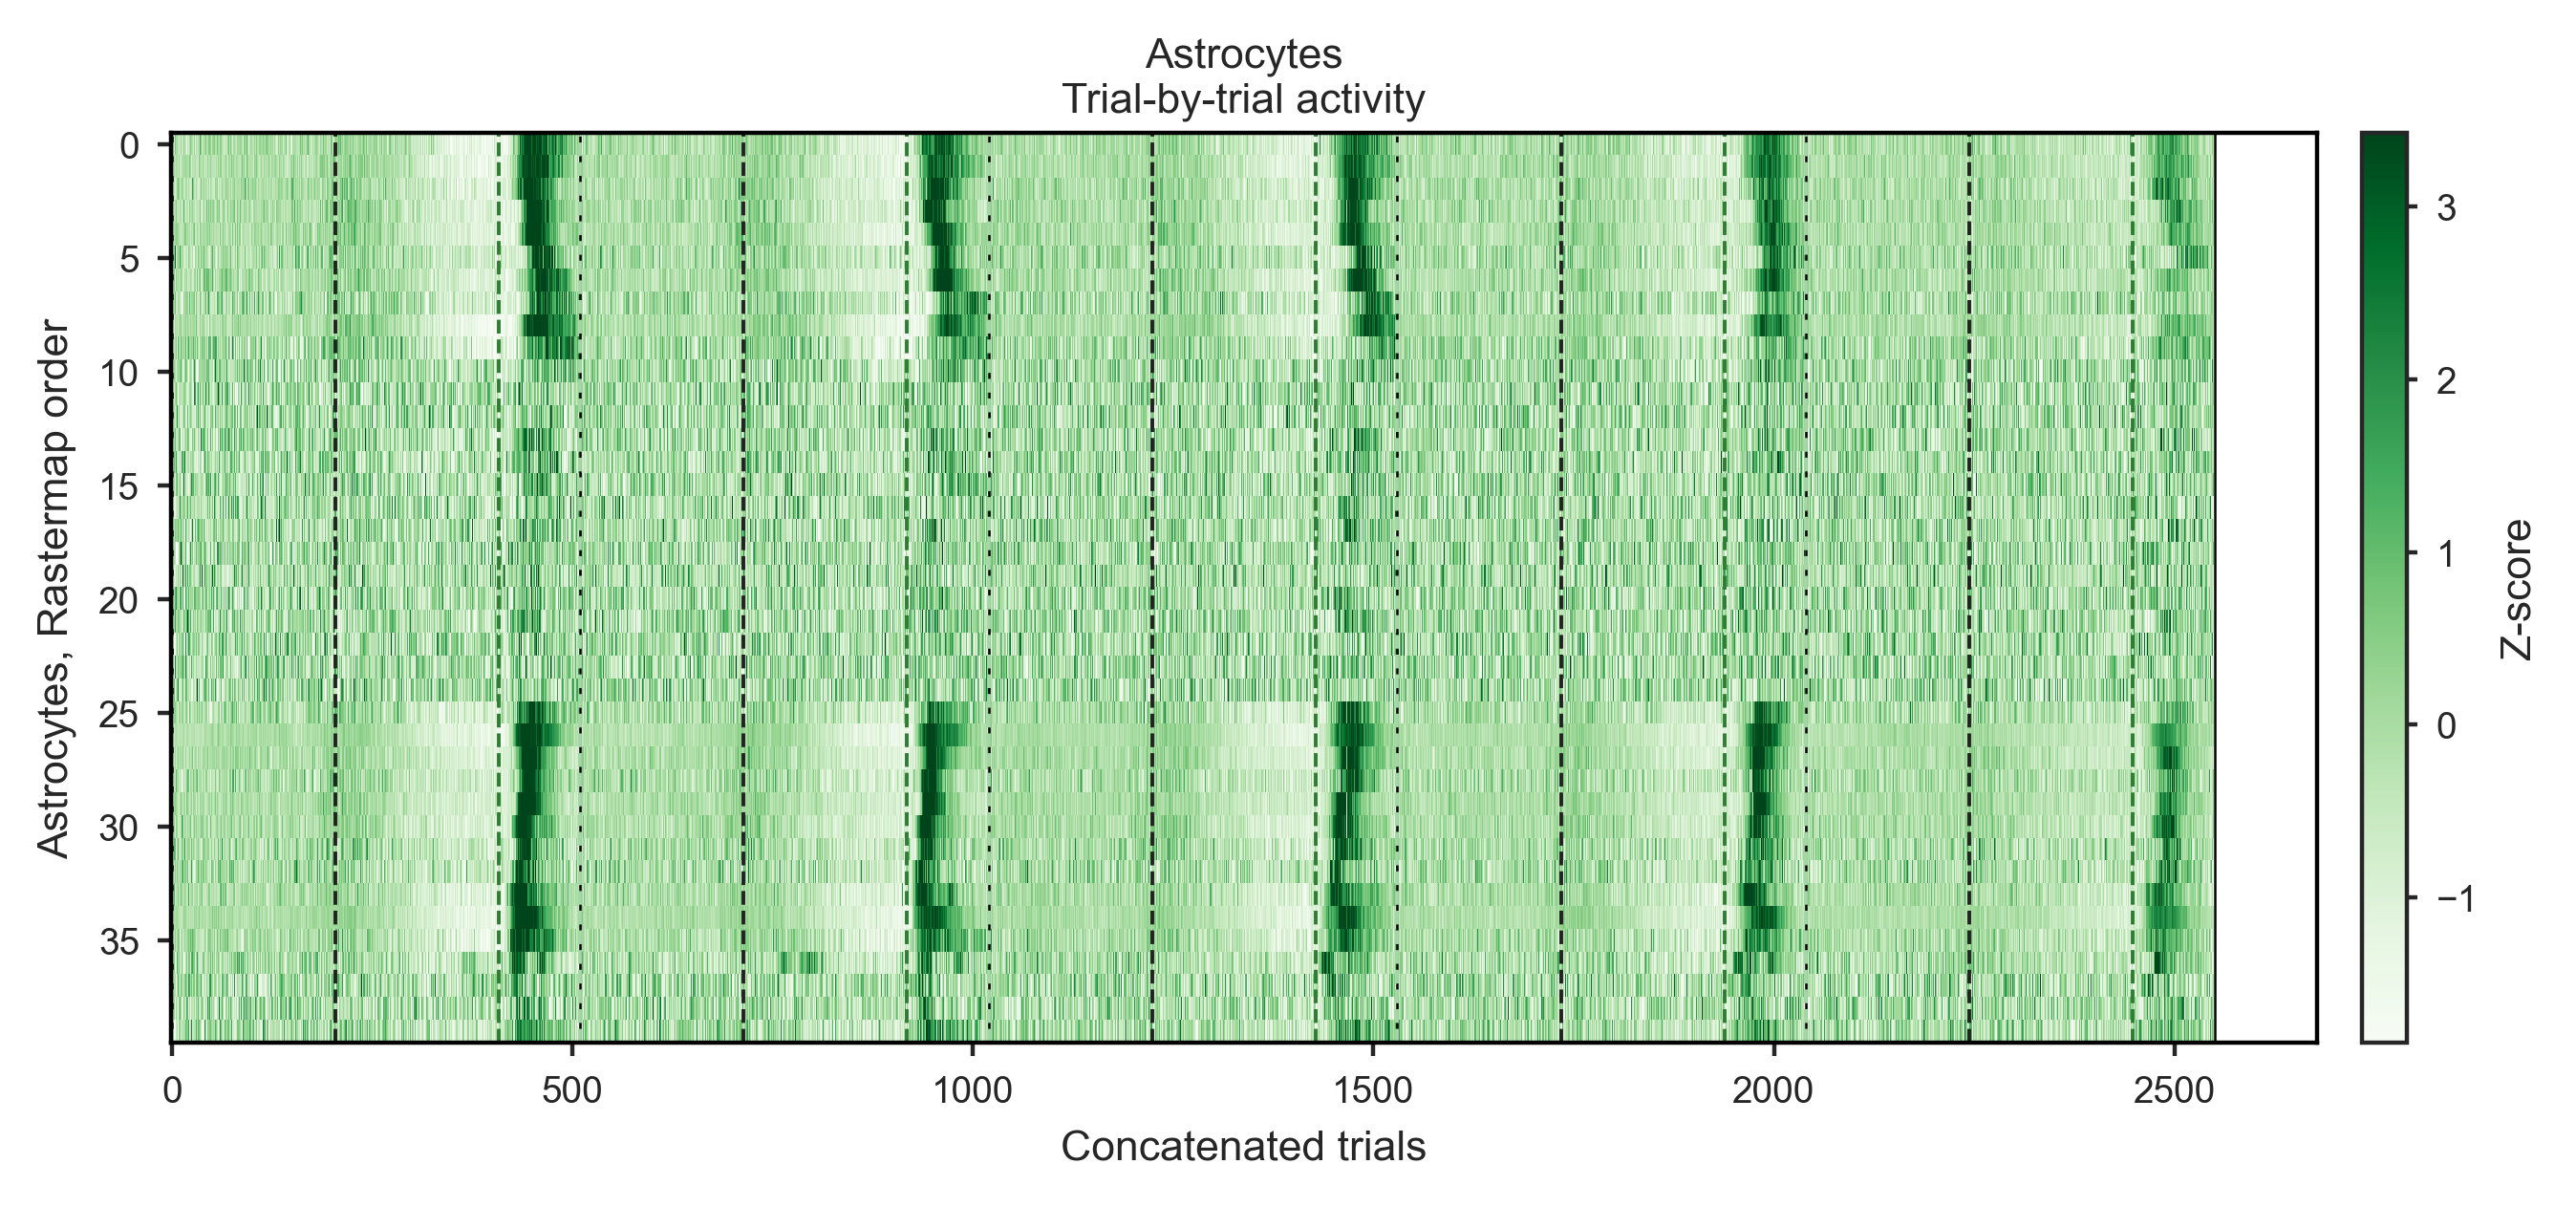

In [57]:
# ESSENTIAL PLOT 3: TRIAL-BY-TRIAL RASTERMAP
# ============================================================

for dataset_name, cfg in DATASETS.items():
    plot_trial_by_trial_rastermap(
        results[dataset_name],
        cfg,
        save_base=output_dirs["trial_by_trial"] / f"{dataset_name}_trial_by_trial_rastermap"
    )

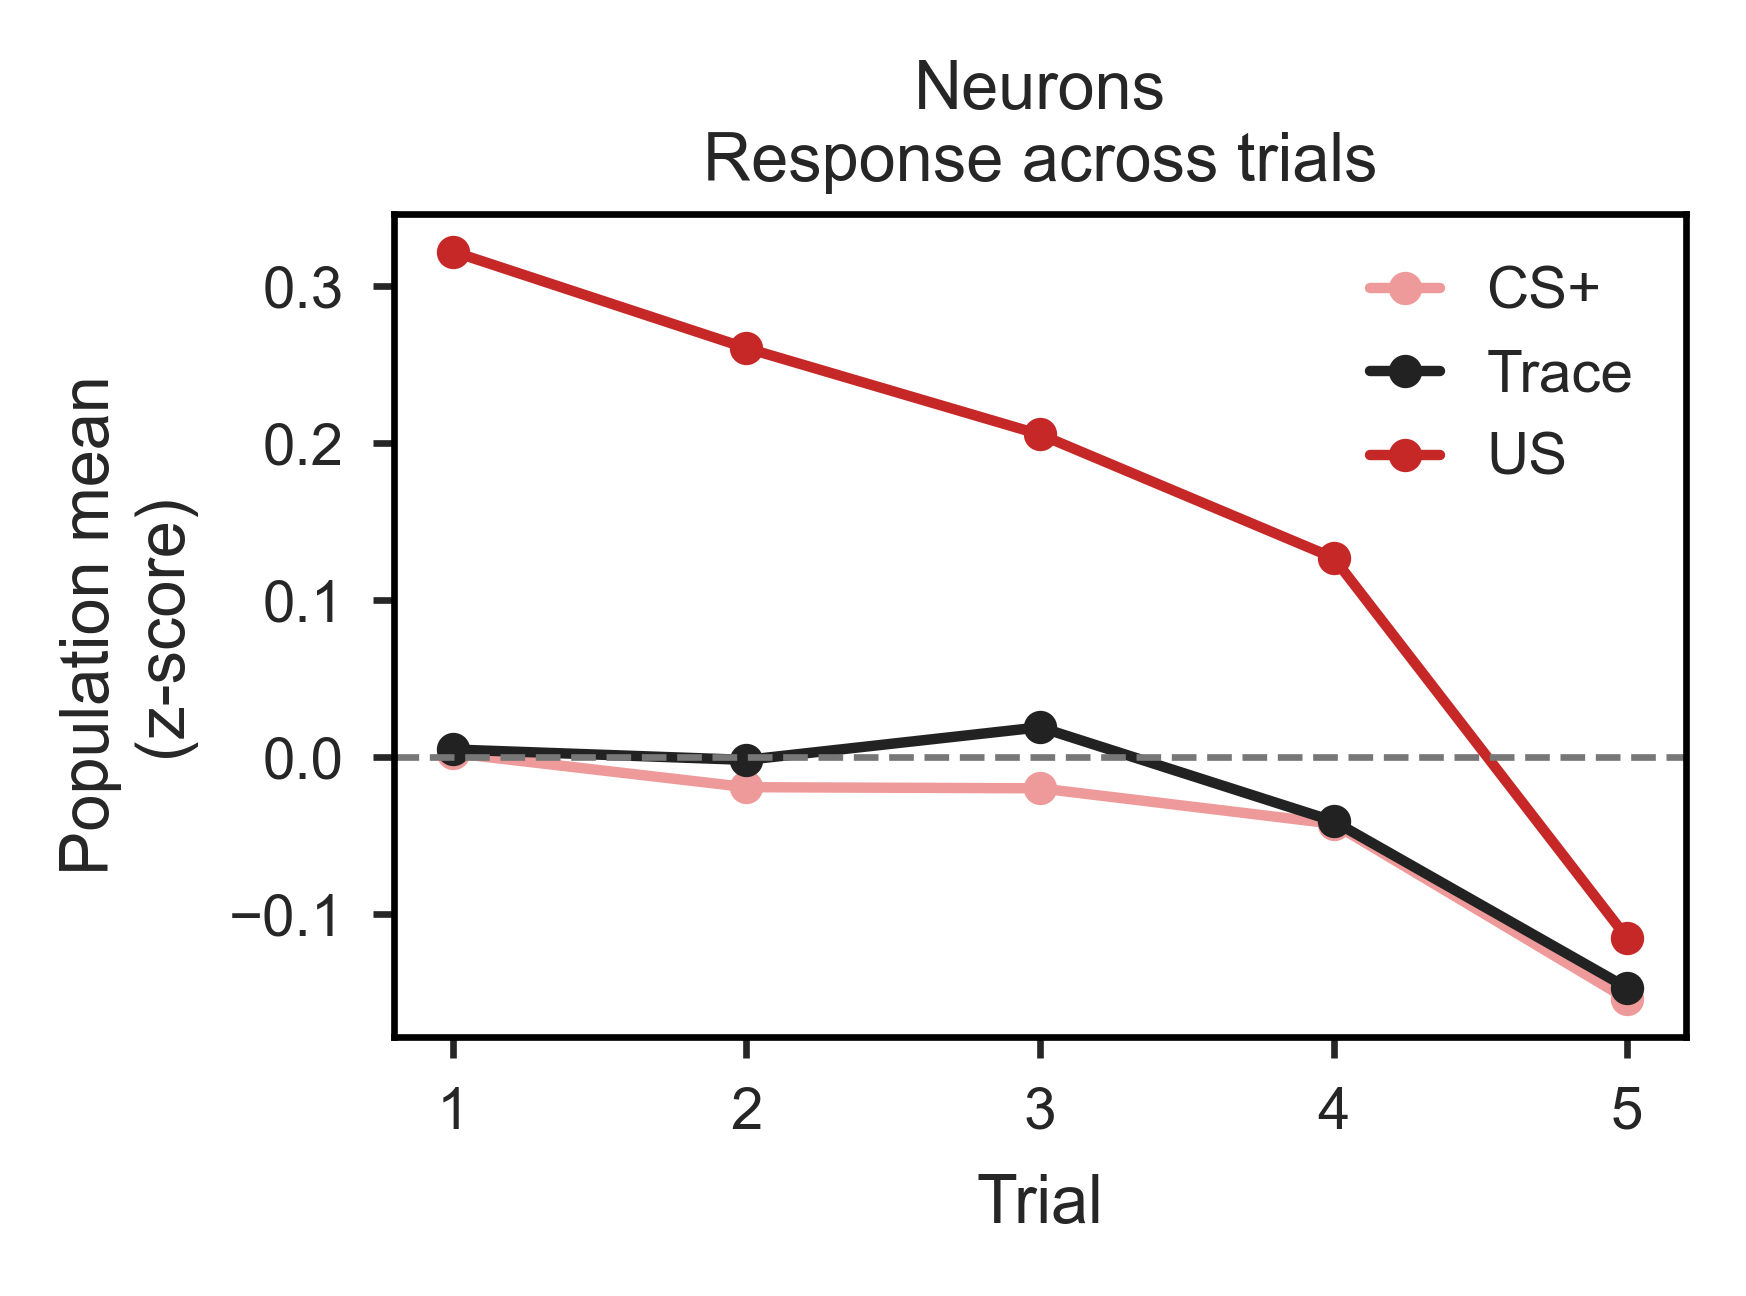

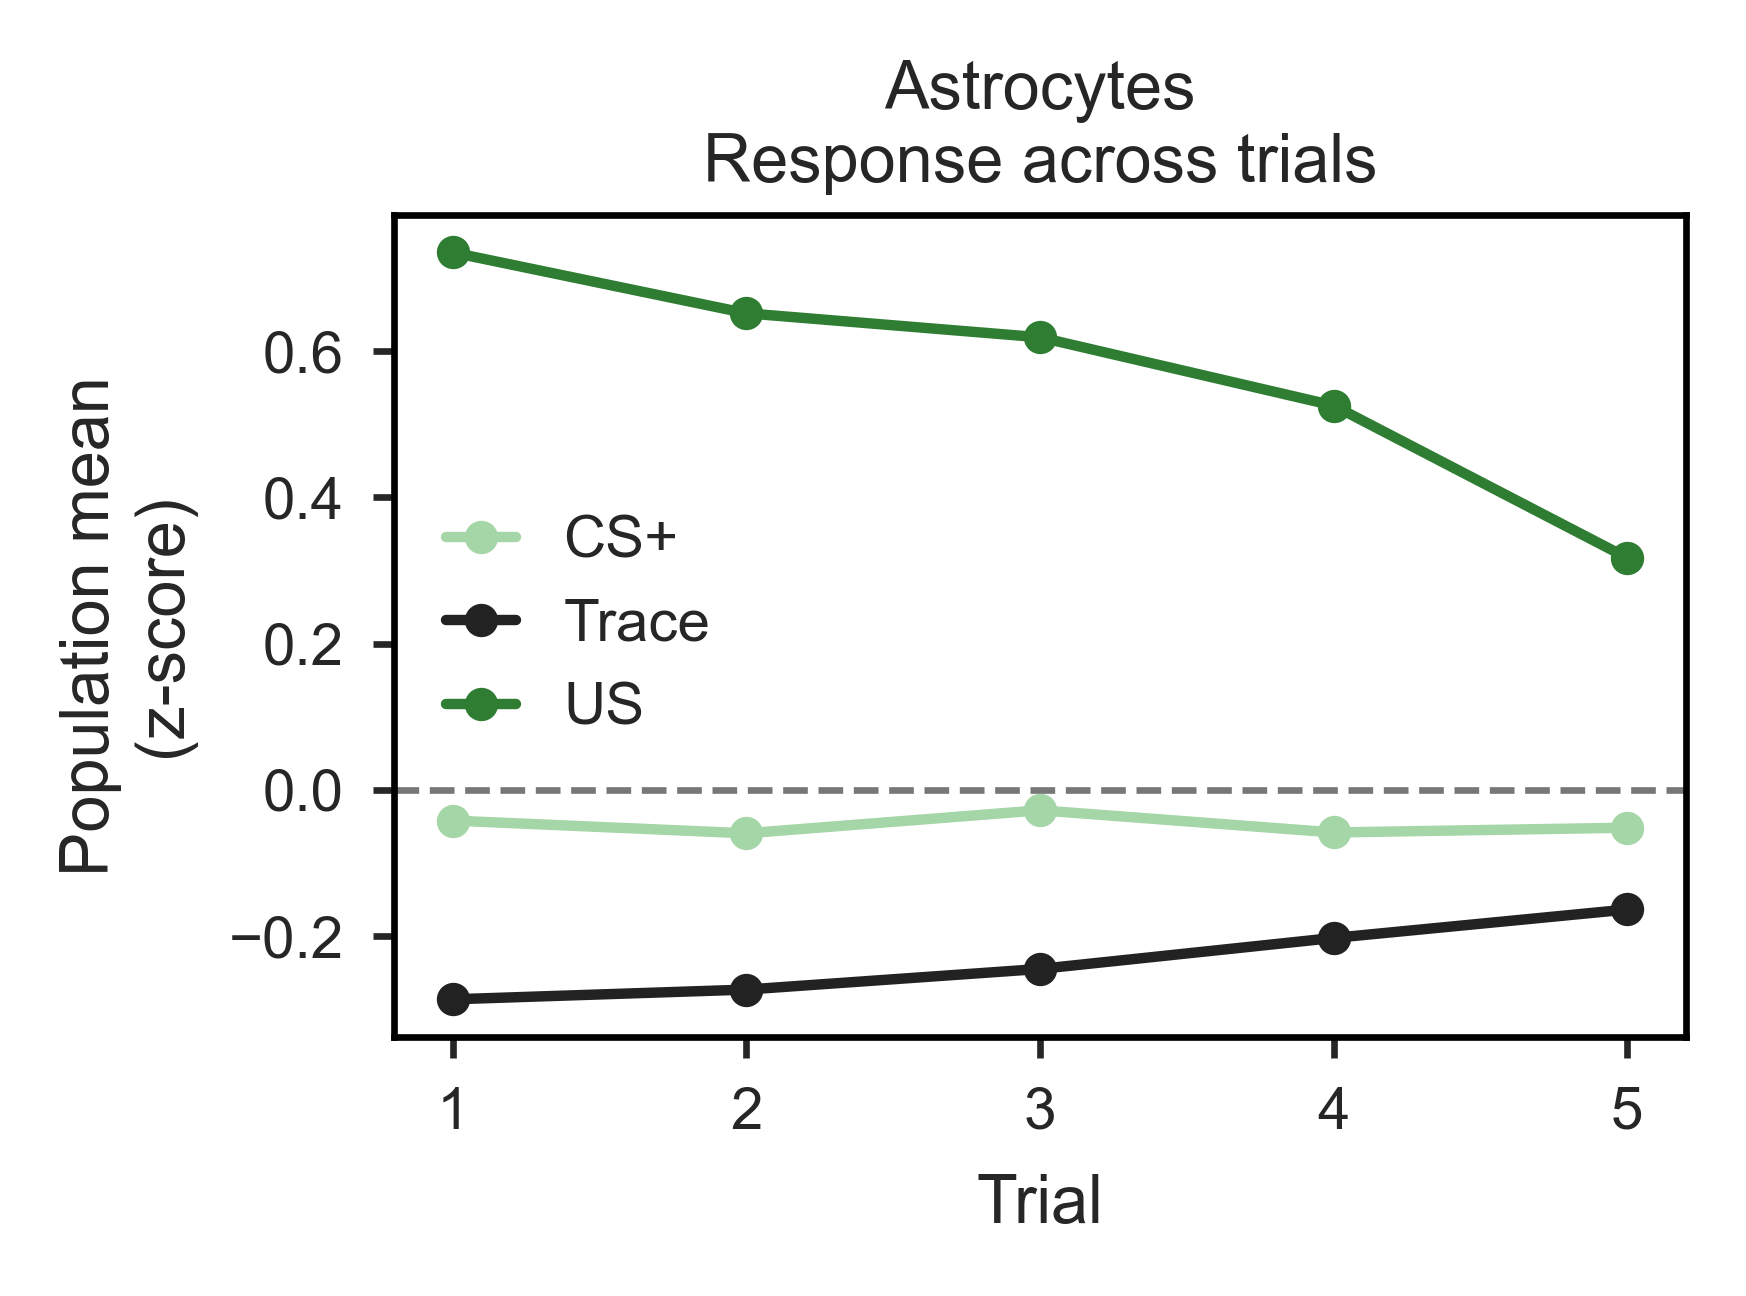

In [58]:
# ESSENTIAL PLOT 4: POPULATION RESPONSE ACROSS TRIALS
# ============================================================

for dataset_name, cfg in DATASETS.items():
    plot_response_across_trials(
        results[dataset_name],
        cfg,
        save_base=output_dirs["trial_by_trial"] / f"{dataset_name}_response_across_trials"
    )

In [75]:
# ESSENTIAL PLOT 5: SHOCK-ALIGNED HEATMAP
# ============================================================

for dataset_name, cfg in DATASETS.items():
    plot_shock_aligned_heatmap(
        results[dataset_name],
        cfg,
        save_base=output_dirs["shock_aligned"] / f"{dataset_name}_shock_aligned_heatmap"
    )

KeyError: 'trace_aligned'

In [60]:
# QUICK ACCESS VARIABLES
# ============================================================

neuron_result = results["neurons"]
astro_result = results["astrocytes"]

neuron_avg = neuron_result["avg_trial_by_cell"]
astro_avg = astro_result["avg_trial_by_cell"]

neuron_trials = neuron_result["trial_data"]
astro_trials = astro_result["trial_data"]

neuron_t_rel = neuron_result["t_rel"]
astro_t_rel = astro_result["t_rel"]

print("Neuron avg shape:", neuron_avg.shape)
print("Astro avg shape:", astro_avg.shape)

Neuron avg shape: (166, 510)
Astro avg shape: (40, 510)


In [61]:
# EVENT-ALIGNED HEATMAP GRID: CS+, TRACE, US
# Rows: neurons, astrocytes
# Columns: CS+, Trace, US
# ============================================================

def make_event_aligned_matrix(
        traces,
        timestamps,
        events,
        window=10,
        sort_by="peak_time",
        zscore_rows=True
):
    """
    Build event-aligned average response matrix.

    Returns:
        z_plot: sorted cells x event-time matrix
        sort_idx: sorting order
        z_unsorted: unsorted cells x event-time matrix
        t_rel_event: event-relative time
    """

    timestamps = np.asarray(timestamps, dtype=float)
    events = np.asarray(events, dtype=float)

    data = ensure_cells_x_time(traces, timestamps)

    fs = 1.0 / np.median(np.diff(timestamps))
    n_points = int(np.round(window * fs))
    t_rel_event = np.arange(n_points) / fs

    all_cells = []

    for sig in data:
        chunks = []

        for event in events:
            t_win = event + t_rel_event

            if t_win[0] < timestamps[0] or t_win[-1] > timestamps[-1]:
                continue

            chunks.append(np.interp(t_win, timestamps, sig))

        if len(chunks) == 0:
            all_cells.append(np.full(n_points, np.nan))
            continue

        all_cells.append(np.nanmean(chunks, axis=0))

    eta_mean = np.vstack(all_cells)

    if zscore_rows:
        z_unsorted = stats.zscore(eta_mean, axis=1, nan_policy="omit")
        z_unsorted = np.nan_to_num(z_unsorted, nan=0.0)
    else:
        z_unsorted = eta_mean.copy()

    if sort_by == "peak_time":
        sort_idx = np.argsort(np.argmax(z_unsorted, axis=1))
    elif sort_by == "max":
        sort_idx = np.argsort(np.nanmax(z_unsorted, axis=1))[::-1]
    elif sort_by is None:
        sort_idx = np.arange(z_unsorted.shape[0])
    else:
        raise ValueError("sort_by must be 'peak_time', 'max', or None")

    z_plot = z_unsorted[sort_idx]

    return z_plot, sort_idx, z_unsorted, t_rel_event

In [71]:
# 2 x 3 EVENT-ALIGNED HEATMAP PLOT
# ============================================================

def plot_event_aligned_2x3_grid(
        results,
        DATASETS,
        window=10,
        sort_by="peak_time",
        save_base=None
):
    """
    2x3 event-aligned heatmap grid.

    Rows:
        neurons
        astrocytes

    Columns:
        CS+, Trace, US
    """

    event_defs = [
        ("CS+", "tone_times"),
        ("Trace", "trace_times"),
        ("US", "shock_times")
    ]

    row_defs = [
        ("neurons", "Neurons"),
        ("astrocytes", "Astrocytes")
    ]

    fig, axes = plt.subplots(
        nrows=2,
        ncols=3,
        figsize=(5.4, 4.2),
        dpi=600,
        sharex=True
    )

    for row_idx, (dataset_name, row_label) in enumerate(row_defs):
        result = results[dataset_name]
        cfg = DATASETS[dataset_name]

        traces = result["traces"]
        timestamps = result["time"]

        for col_idx, (epoch_label, event_key) in enumerate(event_defs):
            ax = axes[row_idx, col_idx]

            z_plot, sort_idx, z_unsorted, t_rel_event = make_event_aligned_matrix(
                traces=traces,
                timestamps=timestamps,
                events=result[event_key],
                window=window,
                sort_by=sort_by,
                zscore_rows=True
            )

            vmin, vmax = np.nanpercentile(z_plot, [1, 99])

            sns.heatmap(
                z_plot,
                ax=ax,
                cmap=cfg["cmap"],
                vmin=vmin,
                vmax=vmax,
                cbar=False,
                xticklabels=False,
                yticklabels=False,
                rasterized=True
            )

            # Event onset line
            ax.axvline(0, color="white", linestyle="--", lw=0.7)

            # X ticks
            tick_secs = [0, 5, 10]
            tick_pos = [
                sec_to_idx(t_rel_event, sec)
                for sec in tick_secs
            ]

            ax.set_xticks(tick_pos)
            ax.set_xticklabels(tick_secs, rotation=0)

            # Y ticks: first and last cell only
            n_cells = z_plot.shape[0]
            ax.set_yticks([0.5, n_cells - 0.5])
            ax.set_yticklabels(["1", str(n_cells)], rotation=0)

            if row_idx == 0:
                ax.set_title(epoch_label, fontsize=9, pad=4)

            if col_idx == 0:
                ax.set_ylabel(cfg["ylabel"], fontsize=8)
            else:
                ax.set_ylabel("")

            if row_idx == 1:
                ax.set_xlabel("Time from onset (s)", fontsize=8)
            else:
                ax.set_xlabel("")

            style_axis(ax)

    # Add separate compact colorbars for each row
    for row_idx, (dataset_name, row_label) in enumerate(row_defs):
        cfg = DATASETS[dataset_name]

        # use last image in row for colorbar scale
        mappable = axes[row_idx, -1].collections[0]

        cbar = fig.colorbar(
            mappable,
            ax=axes[row_idx, :],
            fraction=0.025,
            pad=0.02
        )

        cbar.set_label("Z-score", fontsize=8)
        cbar.ax.tick_params(labelsize=7, width=0.8, length=2)

    fig.suptitle(
        f"Event-aligned responses: first {window} s",
        fontsize=10,
        y=0.995
    )

    # plt.tight_layout(rect=[0, 0, 1, 1])

    if save_base is not None:
        save_figure(fig, save_base, dpi=600)

    plt.show()

    return fig, axes

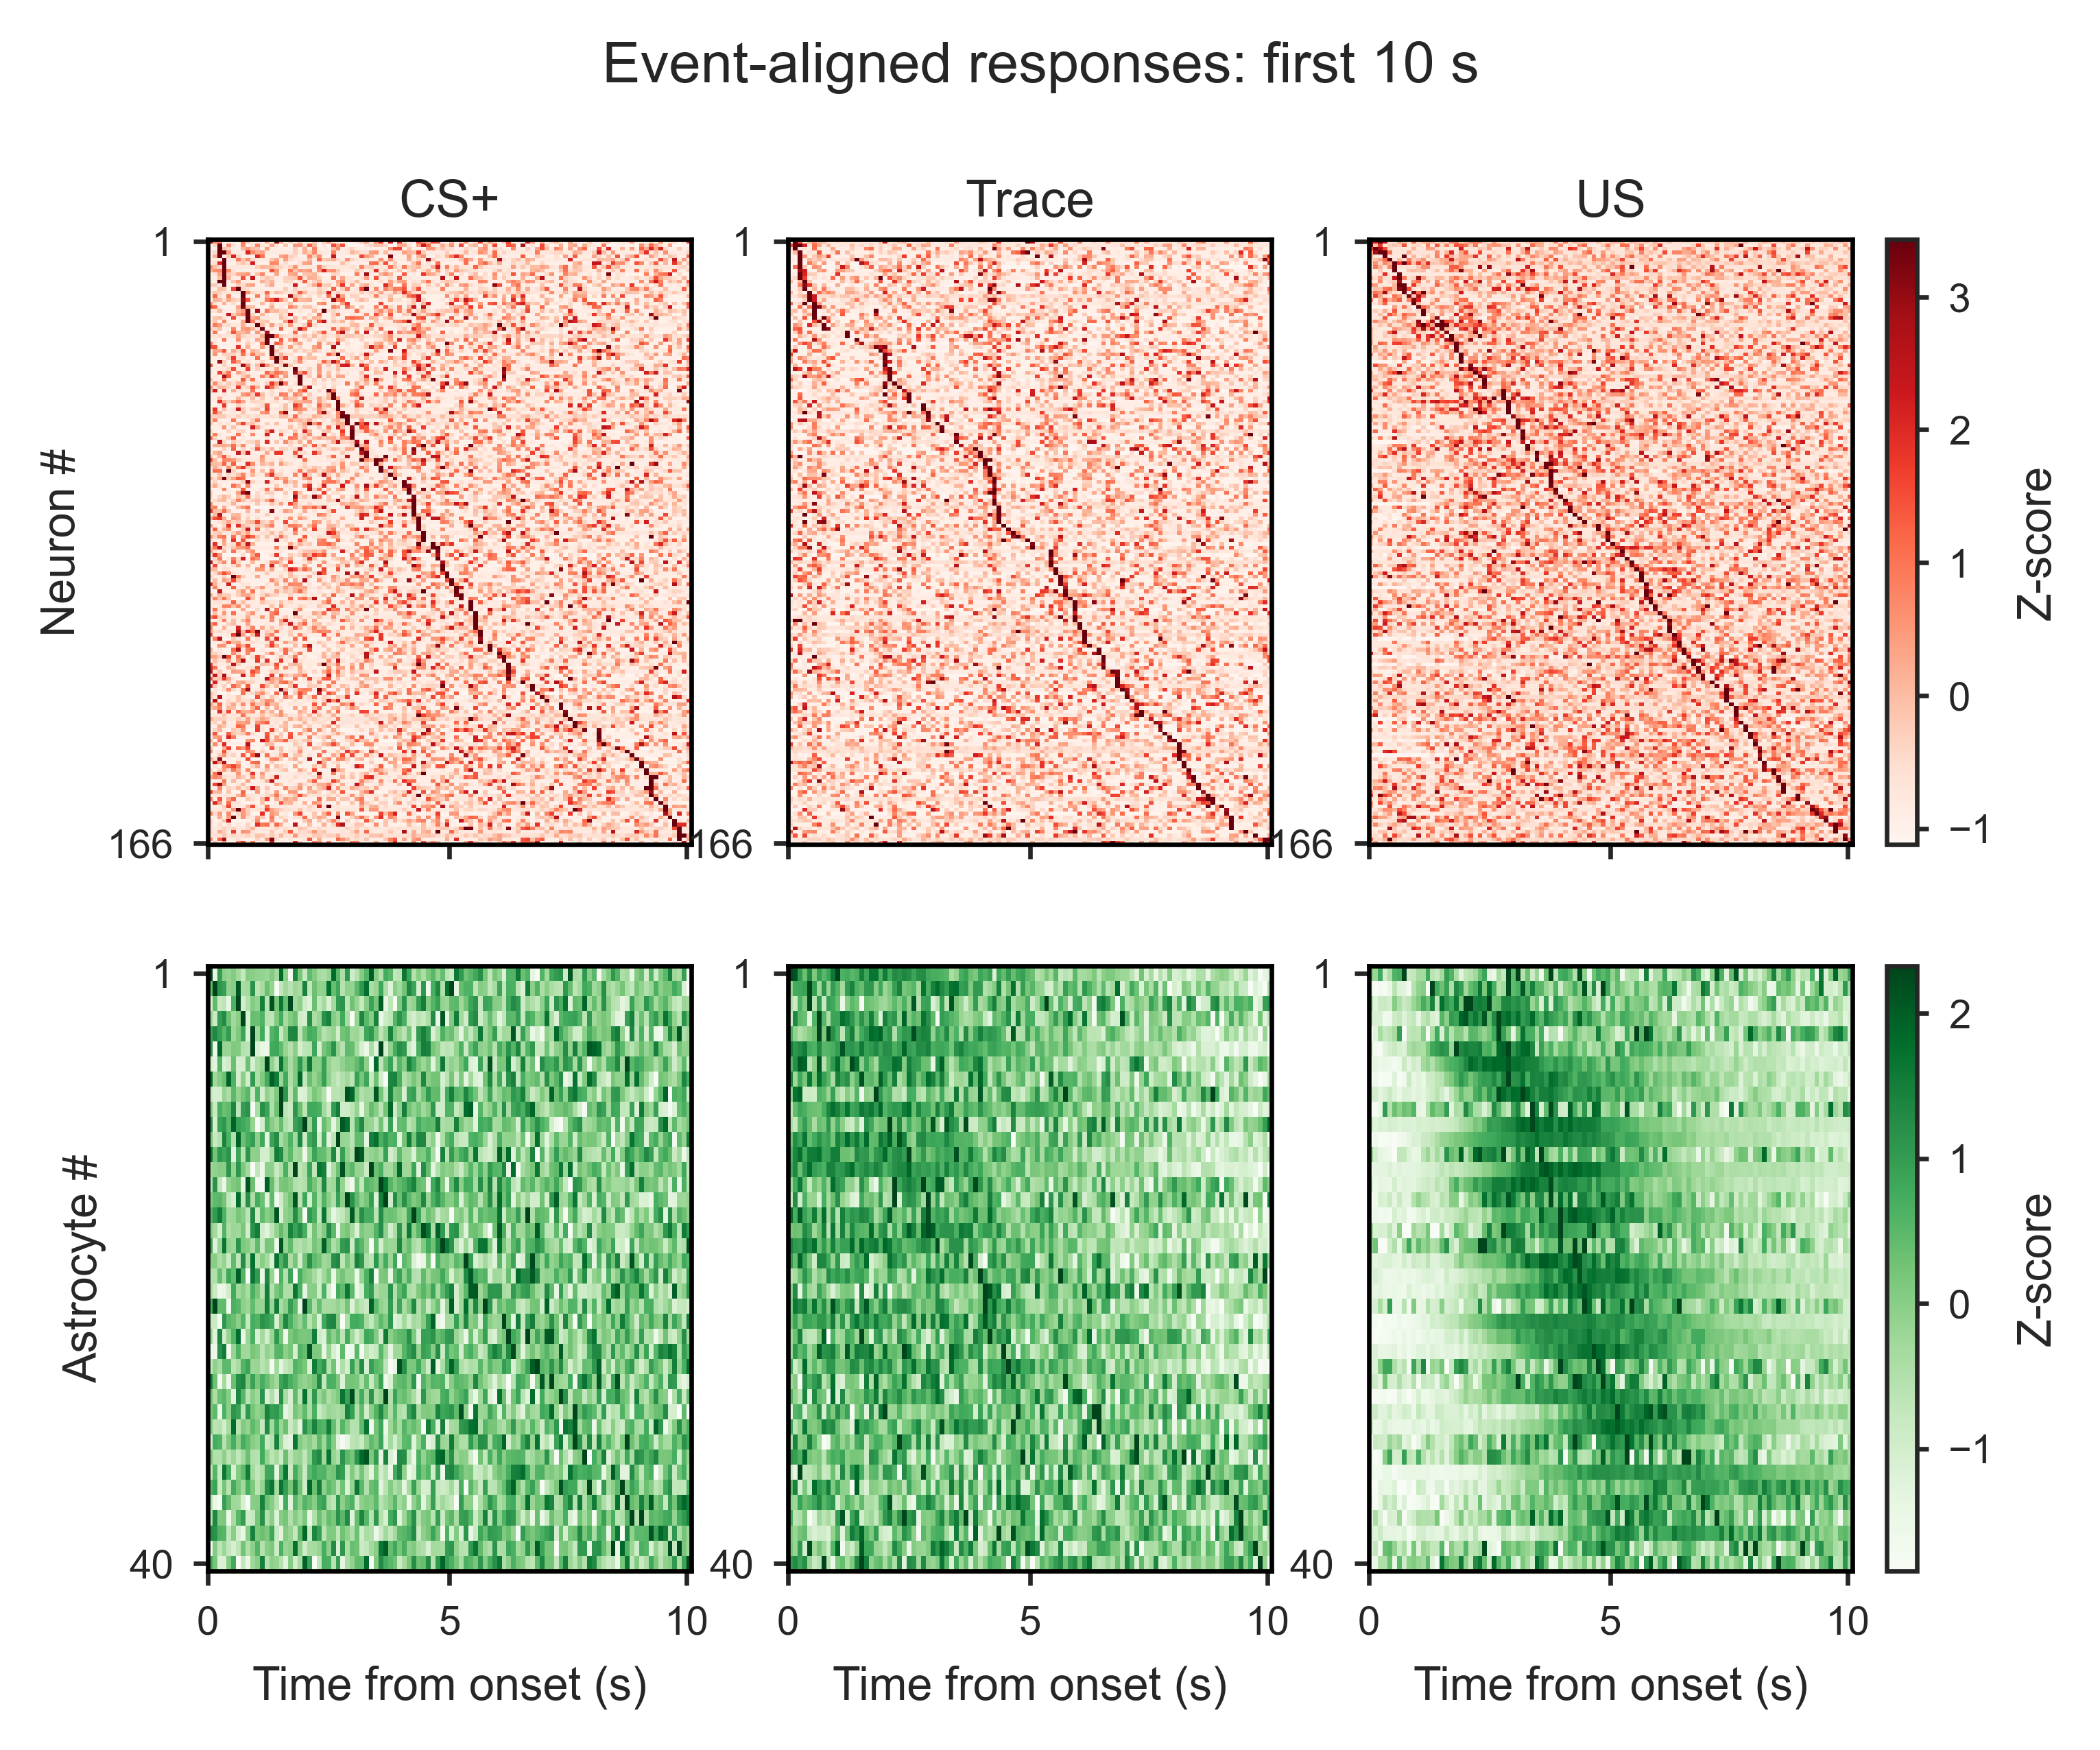

In [72]:
# MAKE 2 x 3 EVENT-ALIGNED HEATMAP GRID
# ============================================================

fig_event_grid, axes_event_grid = plot_event_aligned_2x3_grid(
    results=results,
    DATASETS=DATASETS,
    window=10,
    sort_by="peak_time",
    save_base=output_dirs["shock_aligned"] / "neurons_astrocytes_CS_trace_US_event_aligned_grid"
)

In [76]:
# OPTIONAL PLOT 6: STACKED INDIVIDUAL CELL TRACES
# ============================================================

def get_example_cells(result, mode="US", n_cells=10):
    """
    Select example cells for stacked trace plotting.

    mode options:
        "CS+"        = top CS+-responsive cells
        "Trace"      = top Trace-responsive cells
        "US"         = top US-responsive cells
        "US_max"     = top peak US cells
        "Rastermap"  = first n cells in Rastermap order
    """

    response_df = result["response_df"]

    if mode == "CS+":
        cells = (
            response_df
            .sort_values("CS+", ascending=False)
            ["cell"]
            .head(n_cells)
            .to_numpy()
        )

    elif mode == "Trace":
        cells = (
            response_df
            .sort_values("Trace", ascending=False)
            ["cell"]
            .head(n_cells)
            .to_numpy()
        )

    elif mode == "US":
        cells = (
            response_df
            .sort_values("US", ascending=False)
            ["cell"]
            .head(n_cells)
            .to_numpy()
        )

    elif mode == "US_max":
        cells = (
            response_df
            .sort_values("US_max", ascending=False)
            ["cell"]
            .head(n_cells)
            .to_numpy()
        )

    elif mode == "Rastermap":
        cells = result["raster_order"][:n_cells]

    else:
        raise ValueError("mode must be 'CS+', 'Trace', 'US', 'US_max', or 'Rastermap'")

    return cells

In [77]:
# STACKED TRACE PLOT FUNCTION
# ============================================================

def plot_stacked_individual_cells(
        result,
        cfg,
        mode="US",
        n_cells=20,
        offset_scale=2.5,
        linewidth=1,
        save_base=None
):
    """
    Plot trial-averaged traces for selected individual cells.

    Uses avg_trial_by_cell:
        cells x timepoints

    This means each trace is the average response across trials for that cell.
    """

    avg_trial_by_cell = result["avg_trial_by_cell"]
    t_rel = result["t_rel"]

    cells = get_example_cells(
        result=result,
        mode=mode,
        n_cells=n_cells
    )

    selected_data = avg_trial_by_cell[cells, :]

    fig, ax = plt.subplots(figsize=(4.6, 3.0), dpi=600)

    # Event markers
    ax.axvline(0, color=cfg["epoch_colors"]["CS+"], linestyle="--", lw=0.9)
    ax.axvline(20, color=BLACK, linestyle="--", lw=0.9)
    ax.axvline(40, color=cfg["epoch_colors"]["US"], linestyle="--", lw=0.9)

    offsets = np.arange(n_cells)[::-1] * offset_scale

    for i, cell in enumerate(cells):
        ax.plot(
            t_rel,
            selected_data[i] + offsets[i],
            color=cfg["main_color"],
            lw=linewidth
        )

    # Epoch labels above traces
    y_top = offsets[0] + np.nanmax(selected_data[0]) + 0.8

    ax.text(
        10,
        y_top,
        "CS+",
        color=cfg["epoch_colors"]["CS+"],
        ha="center",
        va="bottom",
        fontweight="bold",
        fontsize=8
    )

    ax.text(
        30,
        y_top,
        "Trace",
        color=BLACK,
        ha="center",
        va="bottom",
        fontsize=8
    )

    ax.text(
        40.5,
        y_top,
        "US",
        color=cfg["epoch_colors"]["US"],
        ha="center",
        va="bottom",
        fontweight="bold",
        fontsize=8
    )

    ax.set_xlim(0, t_rel[-1])
    ax.set_yticks([])
    ax.set_xlabel("Time from CS+ onset (s)")
    ax.set_ylabel("Individual cells\n(z-score)")
    ax.set_title(f"{cfg['label']}\nTop {n_cells} {mode} cells", pad=4)

    sns.despine(ax=ax)
    ax.spines["left"].set_visible(True)
    ax.spines["bottom"].set_visible(True)
    ax.tick_params(width=0.8, length=2.5)

    plt.tight_layout()

    if save_base is not None:
        save_figure(fig, save_base, dpi=600)

    plt.show()

    return fig, ax, cells

In [78]:
# Add this near your output_dirs definition
output_dirs["individual_cells"] = output_root / "06_individual_cells"
output_dirs["individual_cells"].mkdir(parents=True, exist_ok=True)

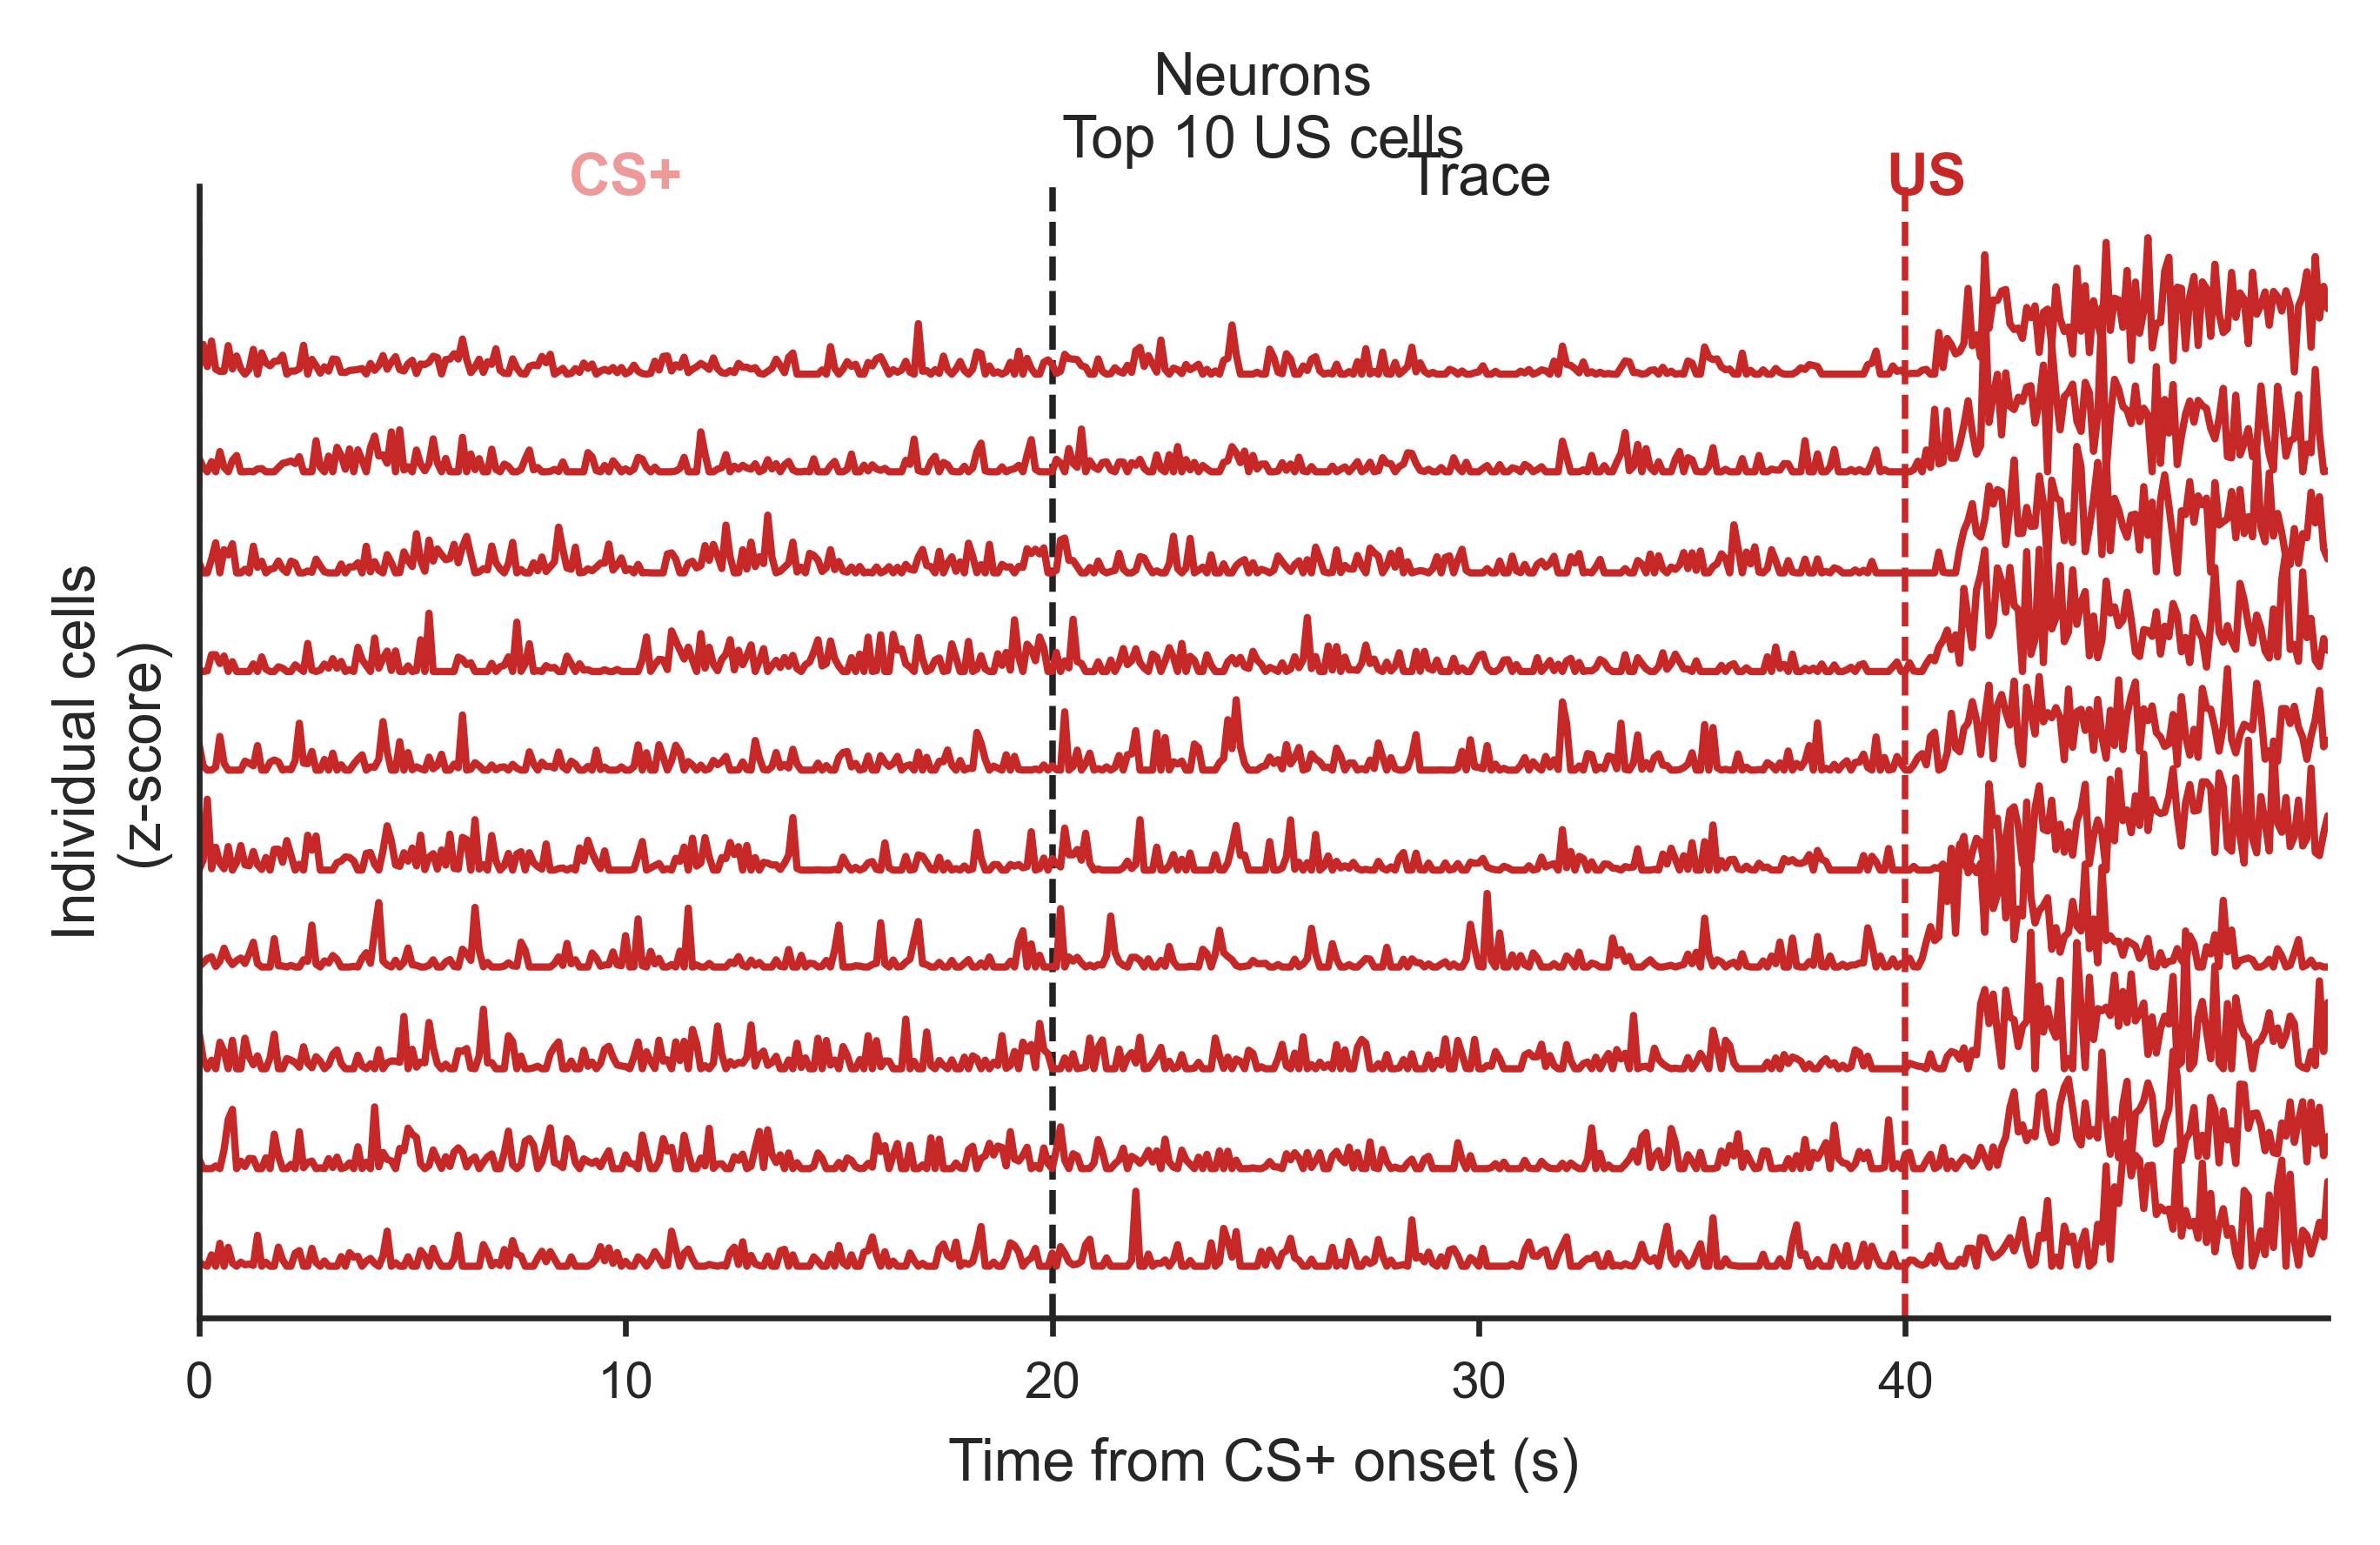

neurons top US cells: [ 74  20  13 156  38  12  80  29 117  57]


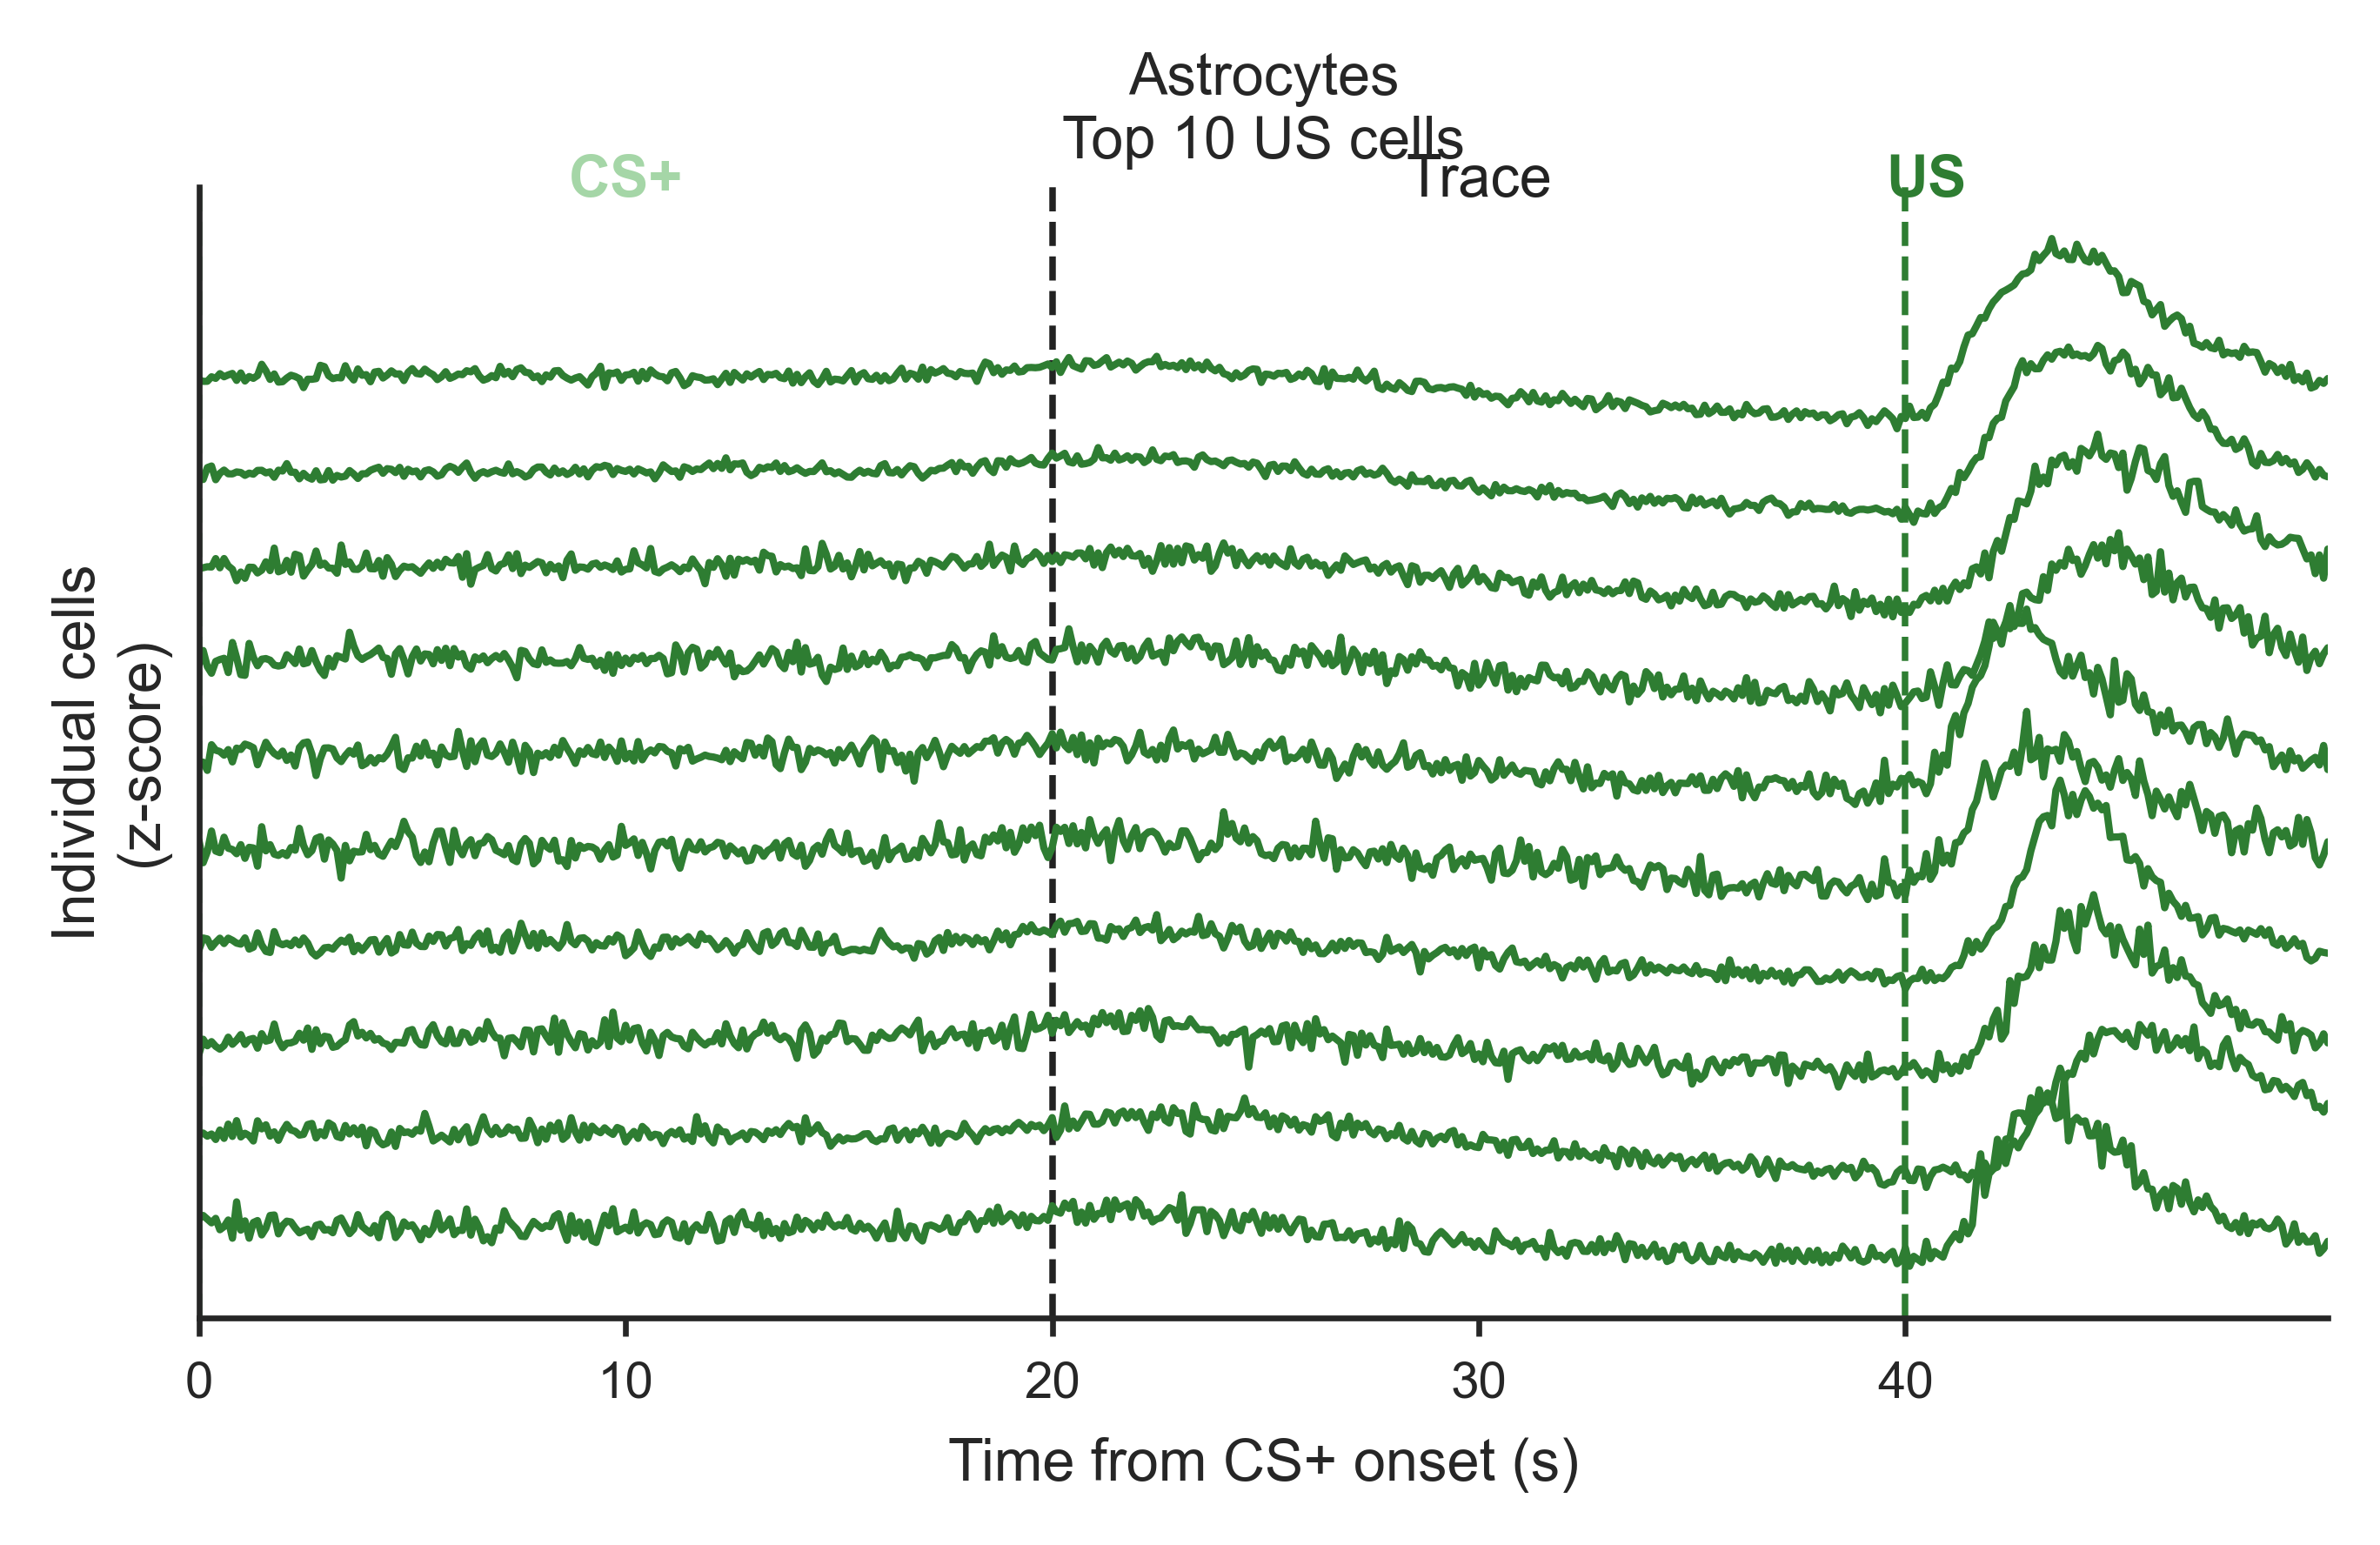

astrocytes top US cells: [13 27  7 16  8 15 39  4 36 31]


In [83]:
# OPTIONAL PLOT 6: INDIVIDUAL TOP US CELLS
# ============================================================

for dataset_name, cfg in DATASETS.items():
    fig, ax, cells = plot_stacked_individual_cells(
        result=results[dataset_name],
        cfg=cfg,
        mode="US",
        n_cells=10,
        offset_scale=2.5,
        linewidth=1,
        save_base=output_dirs["individual_cells"] / f"{dataset_name}_top10_US_individual_cells"
    )

    print(dataset_name, "top US cells:", cells)

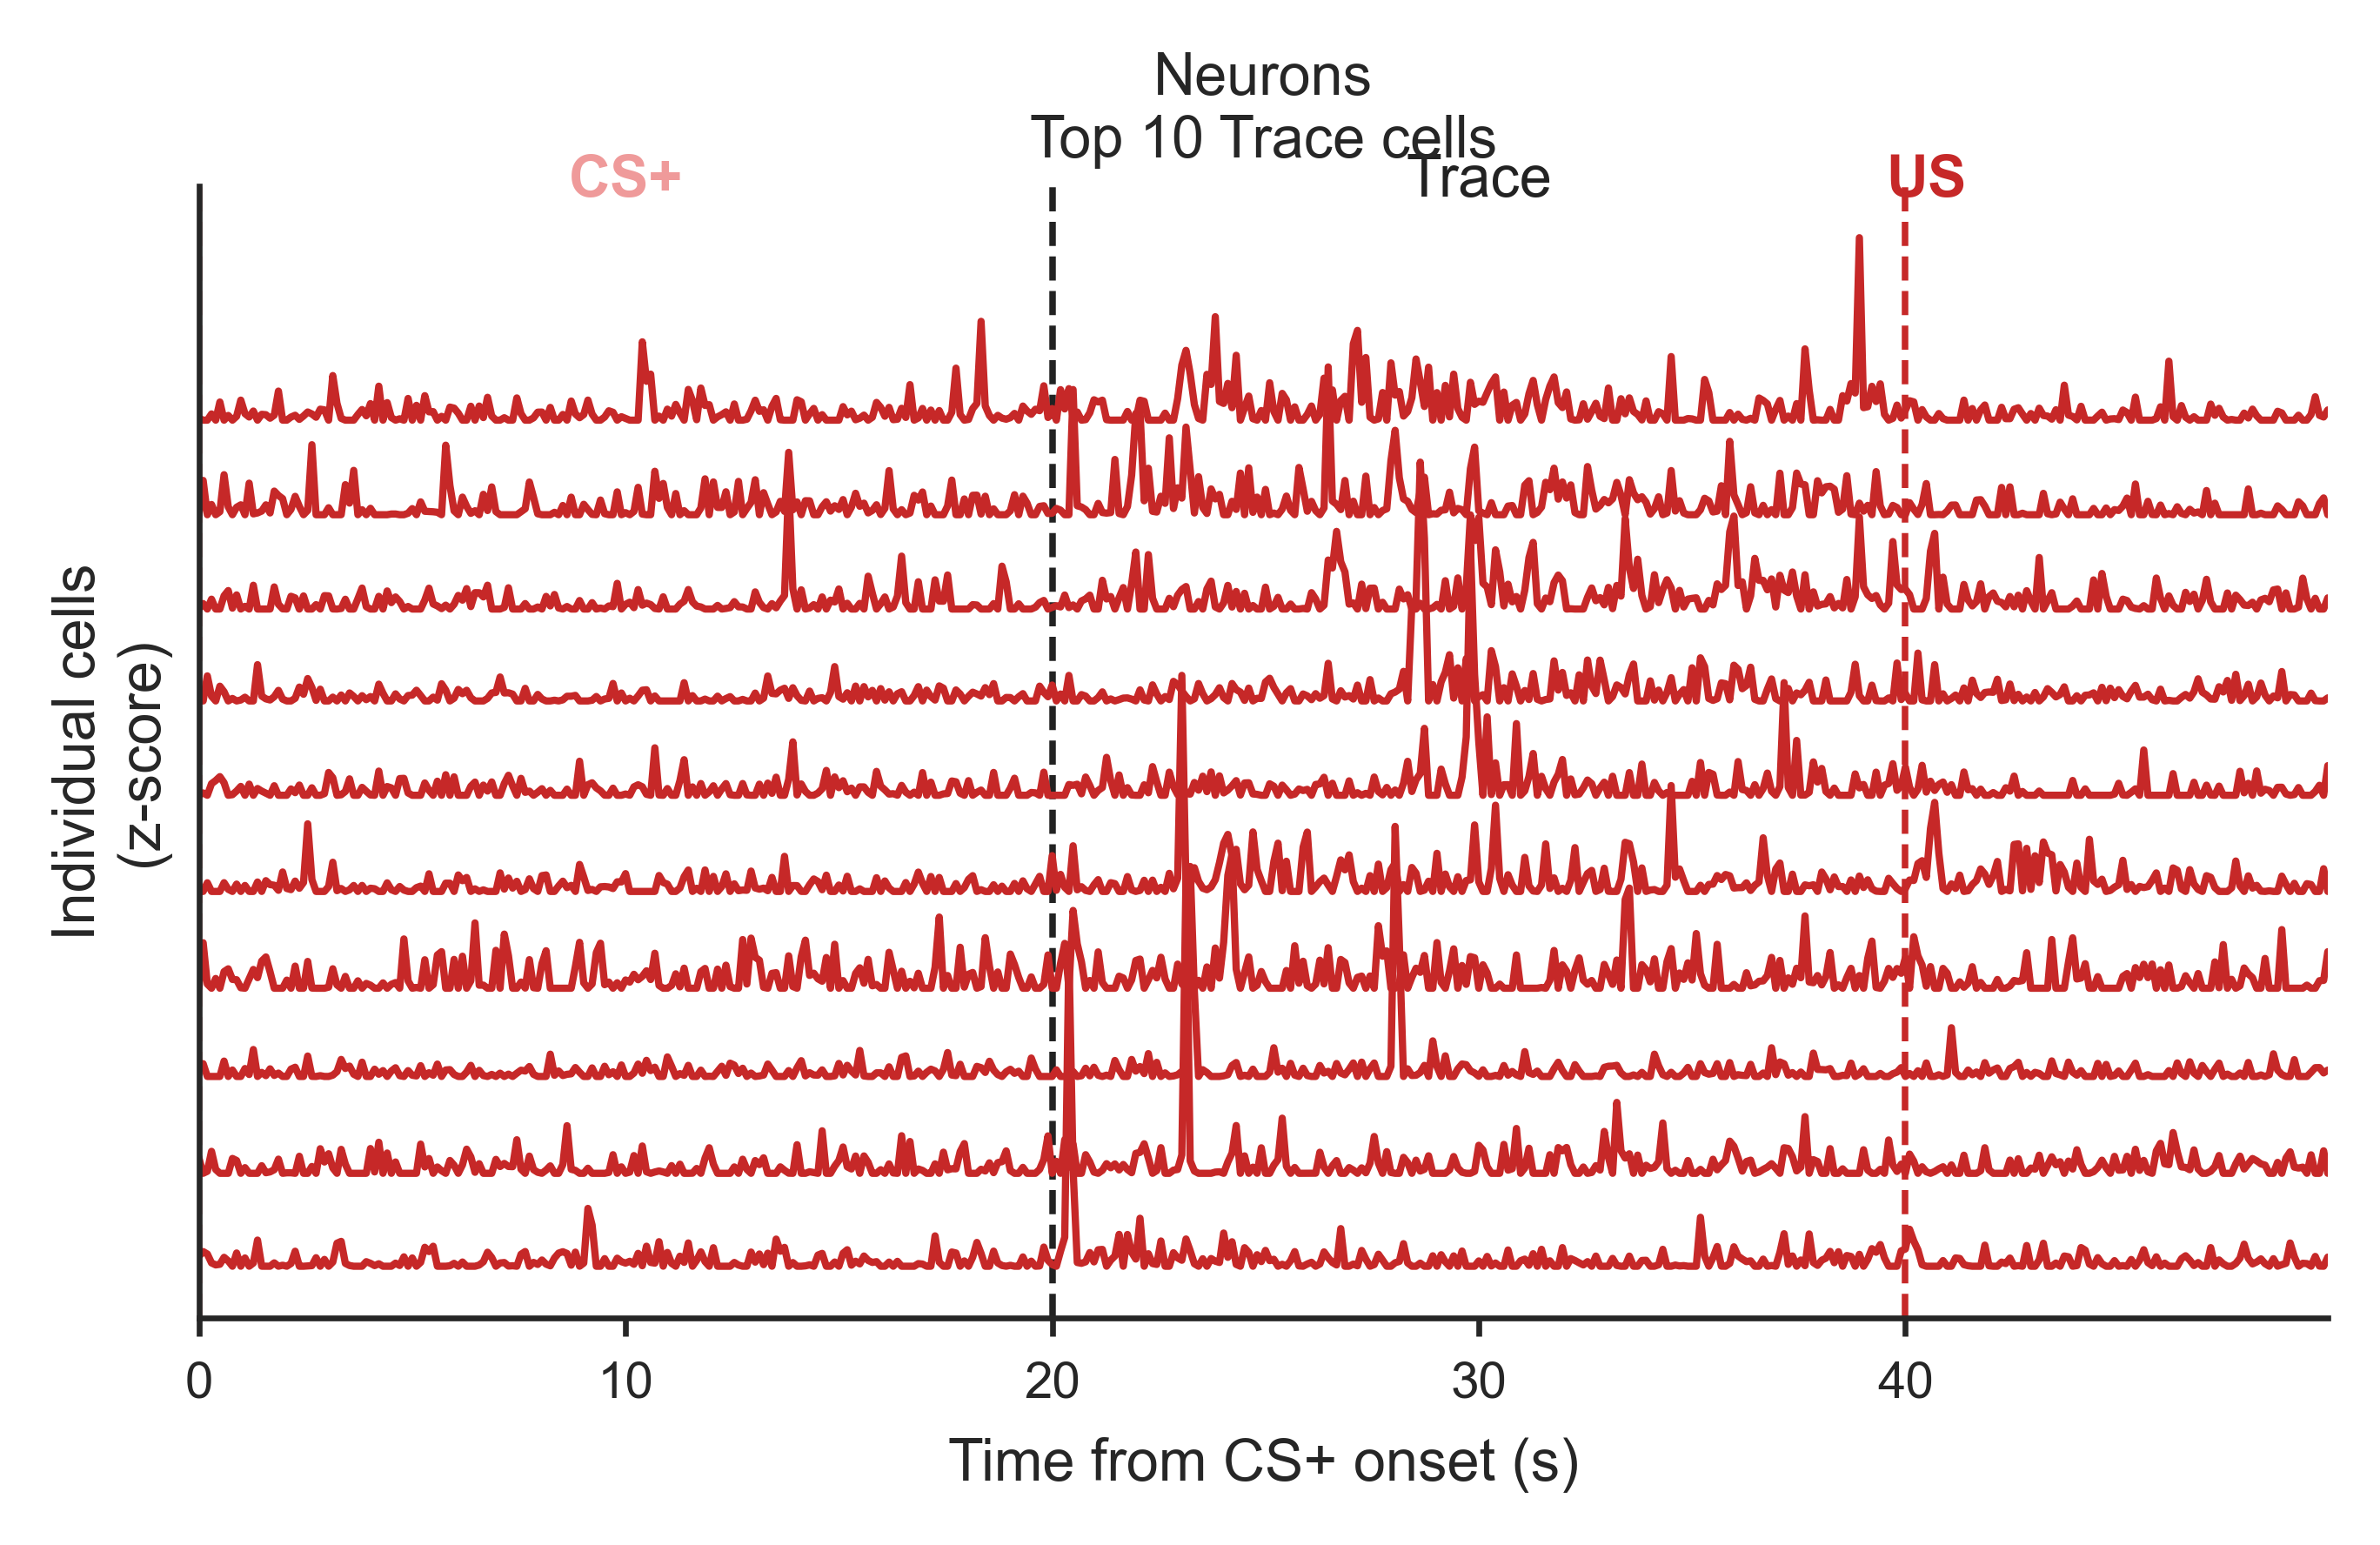

neurons top Trace cells: [133 103  40 152   2 162 126 112 129 142]


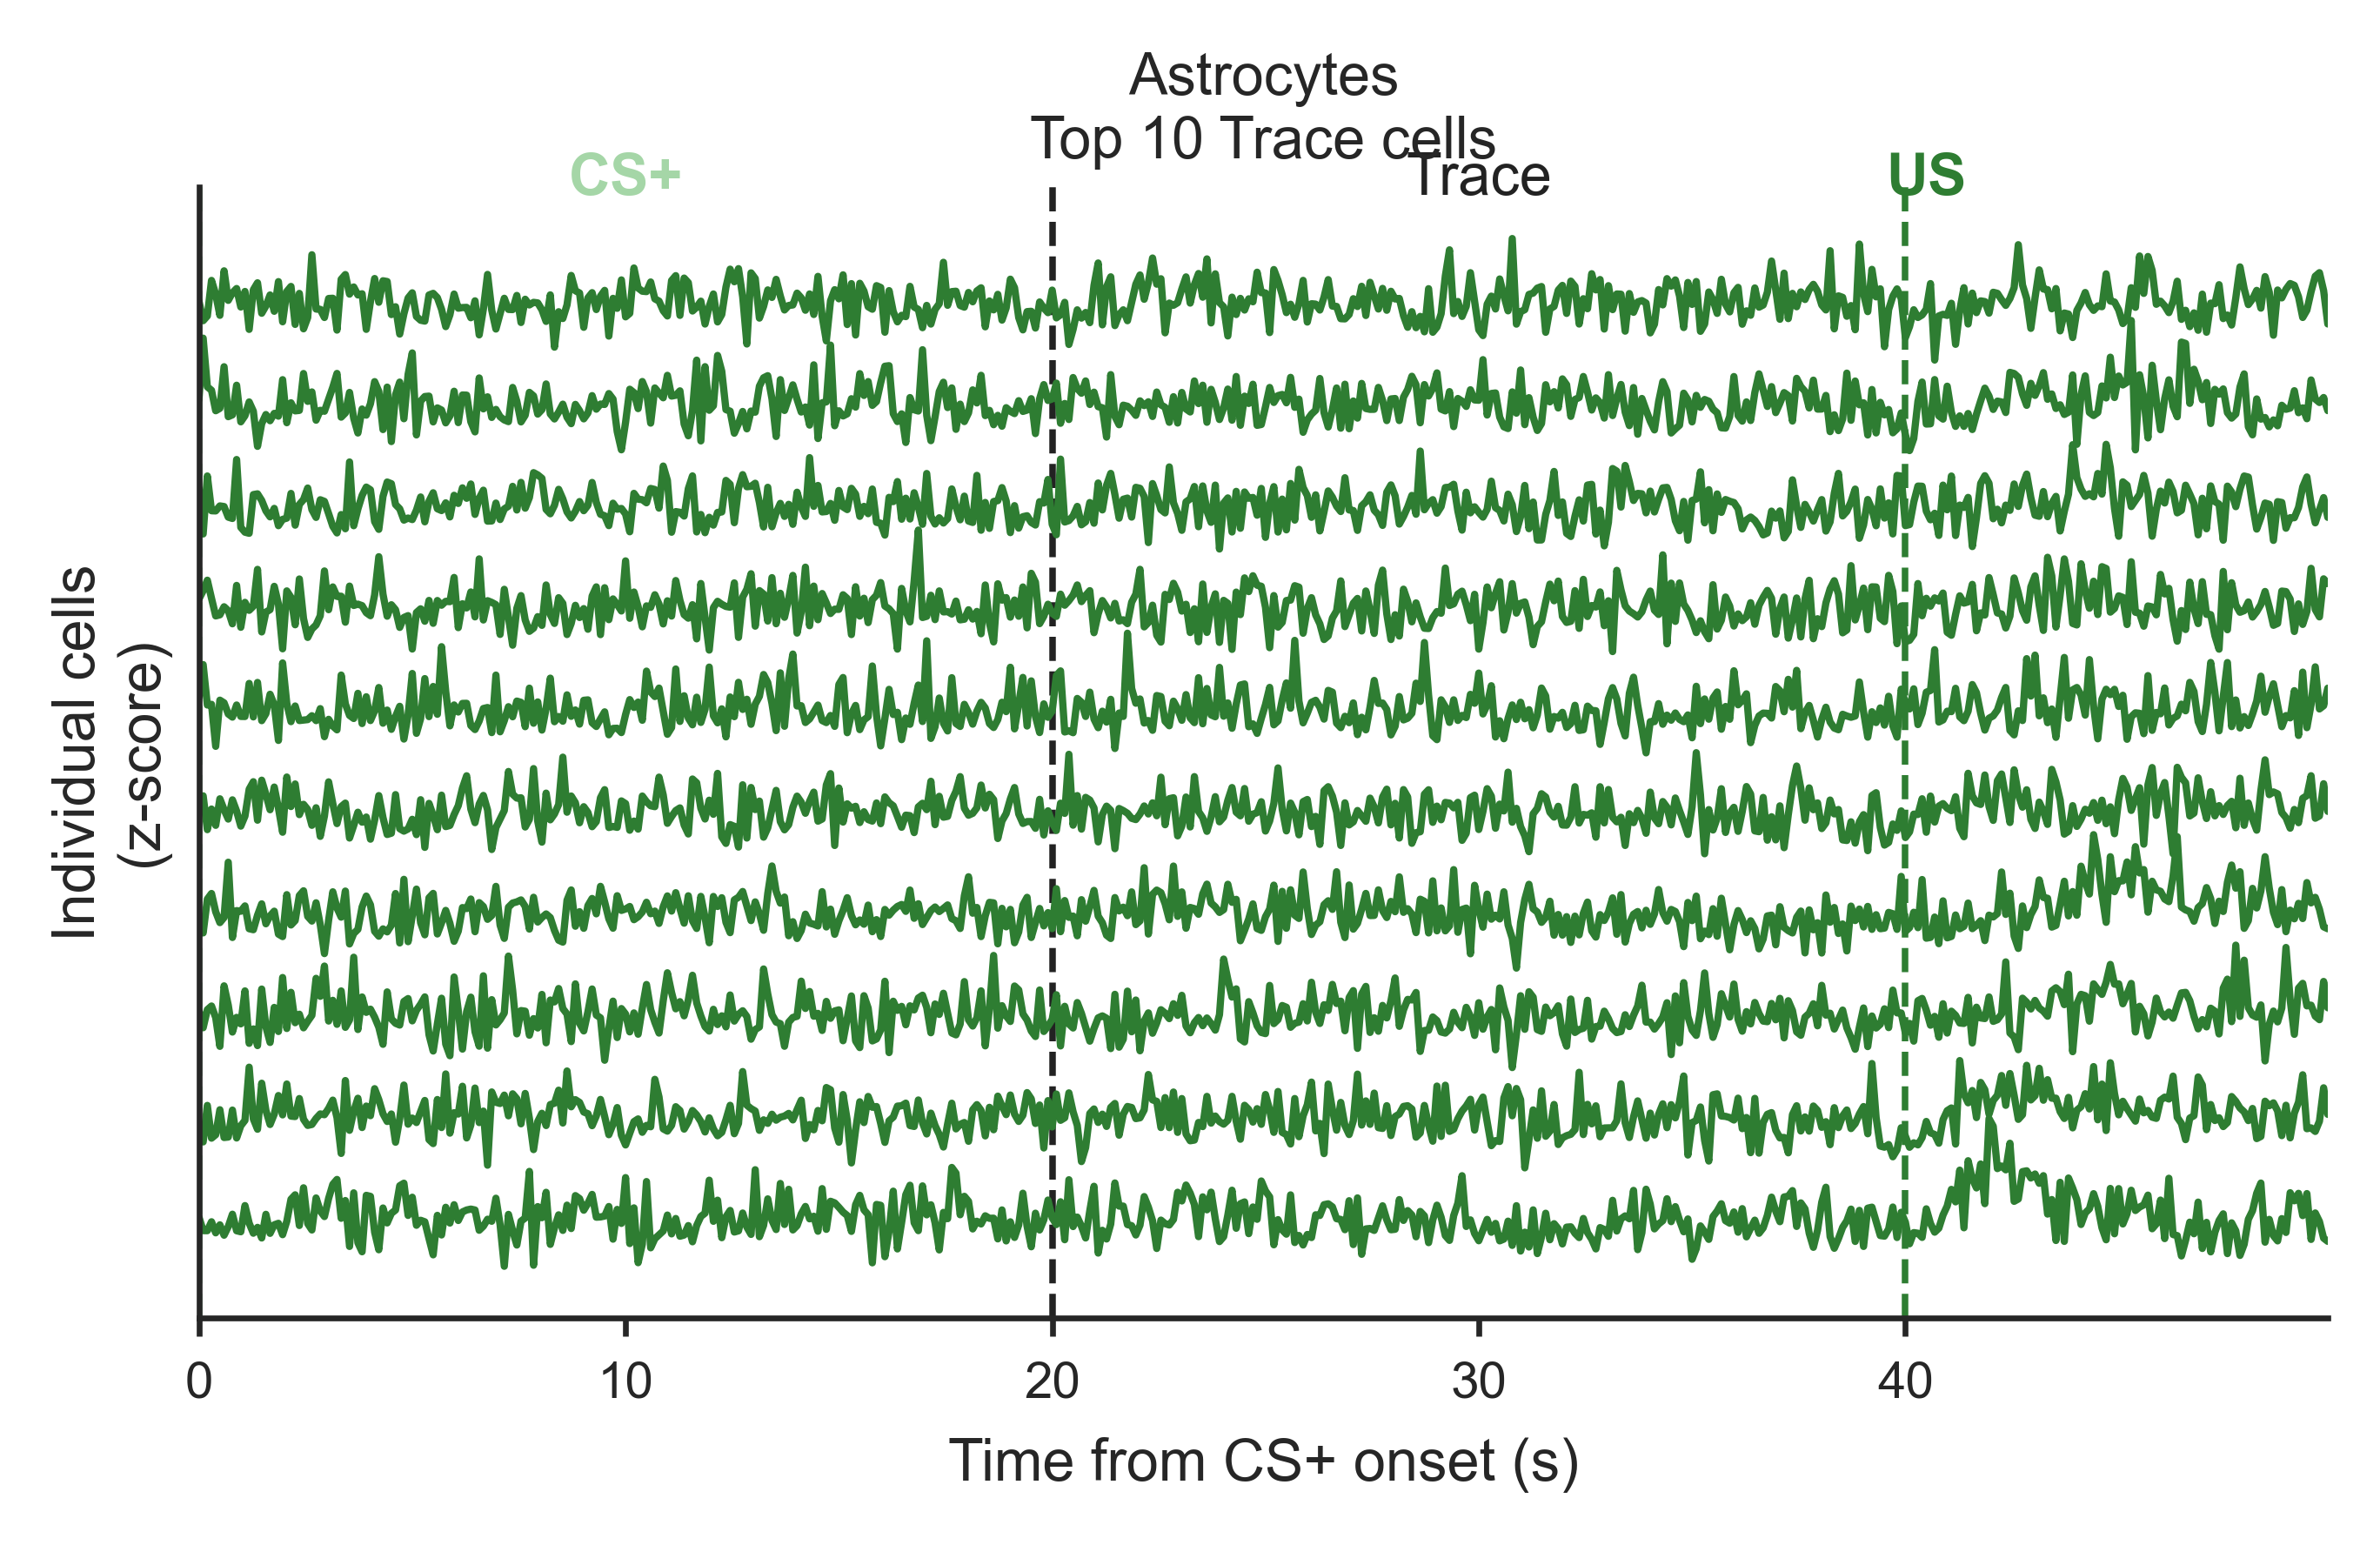

astrocytes top Trace cells: [23 17 30 11  6 14 10 19 21  1]


In [84]:

for dataset_name, cfg in DATASETS.items():
    fig, ax, cells = plot_stacked_individual_cells(
        result=results[dataset_name],
        cfg=cfg,
        mode="Trace",
        n_cells=10,
        offset_scale=2.5,
        linewidth=1,
        save_base=output_dirs["individual_cells"] / f"{dataset_name}_top10_trace_individual_cells"
    )

    print(dataset_name, "top Trace cells:", cells)

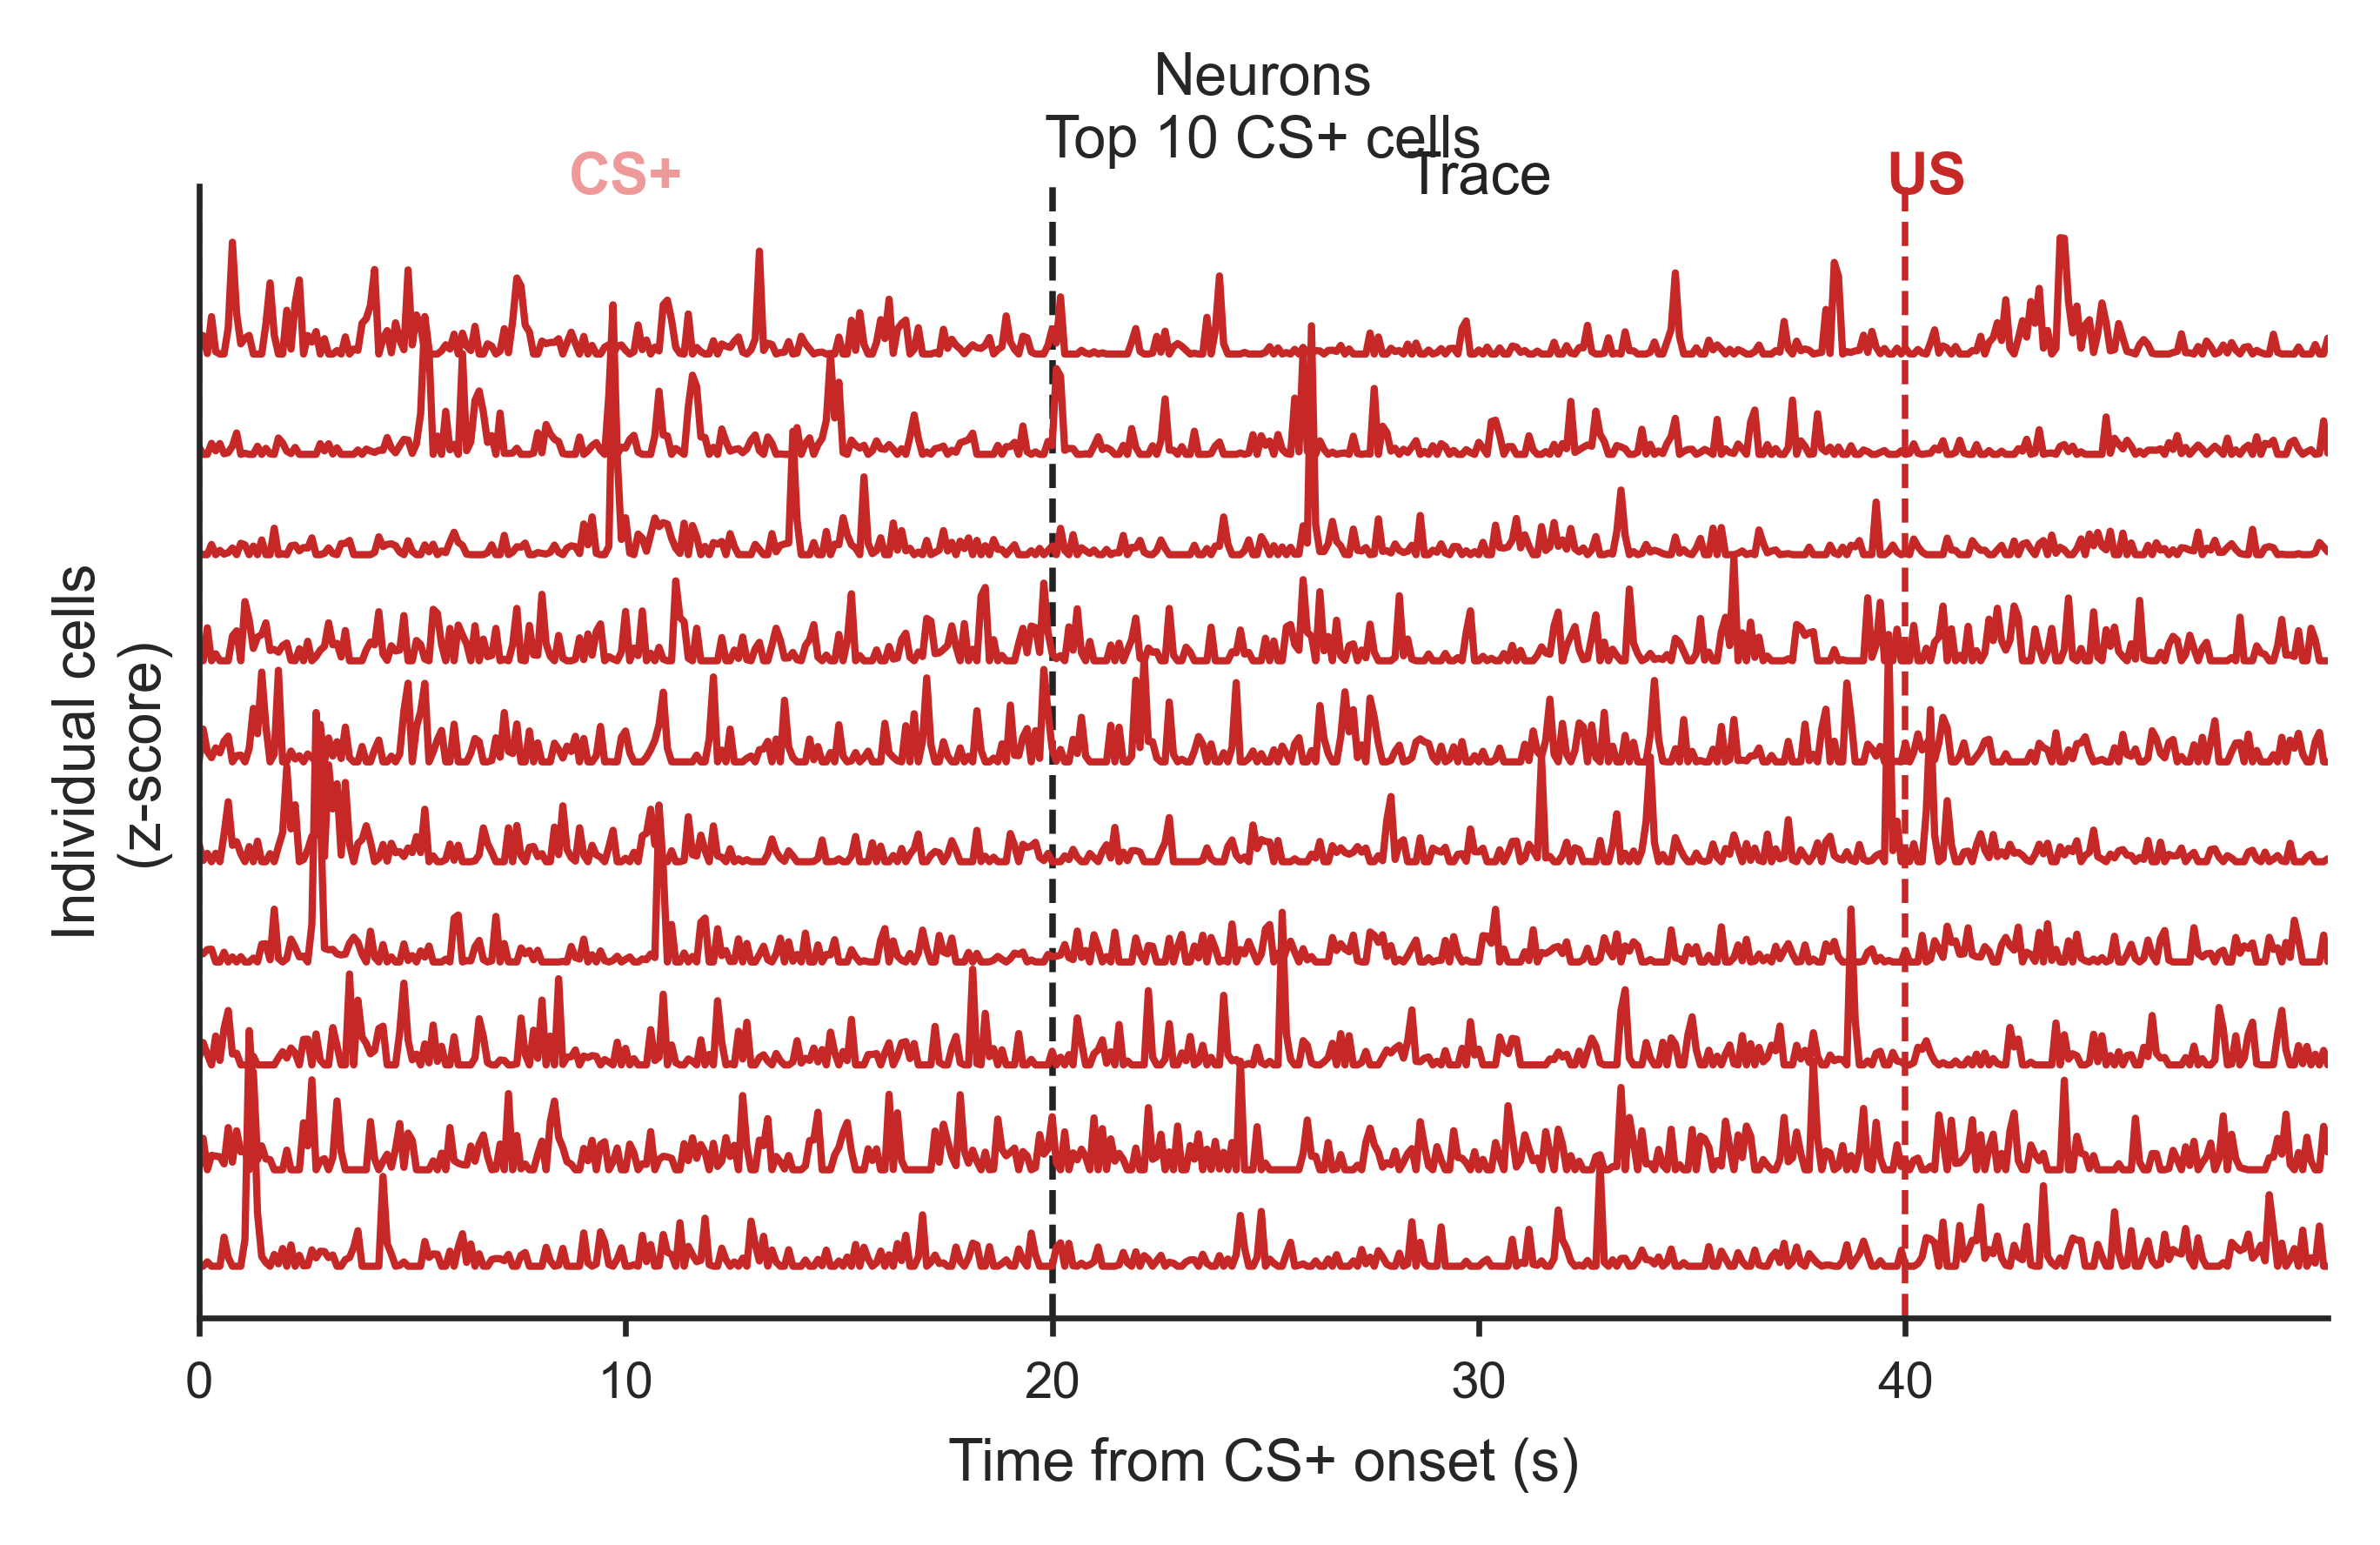

neurons top CS+ cells: [113   1  28  49  17  21  39  25  67 165]


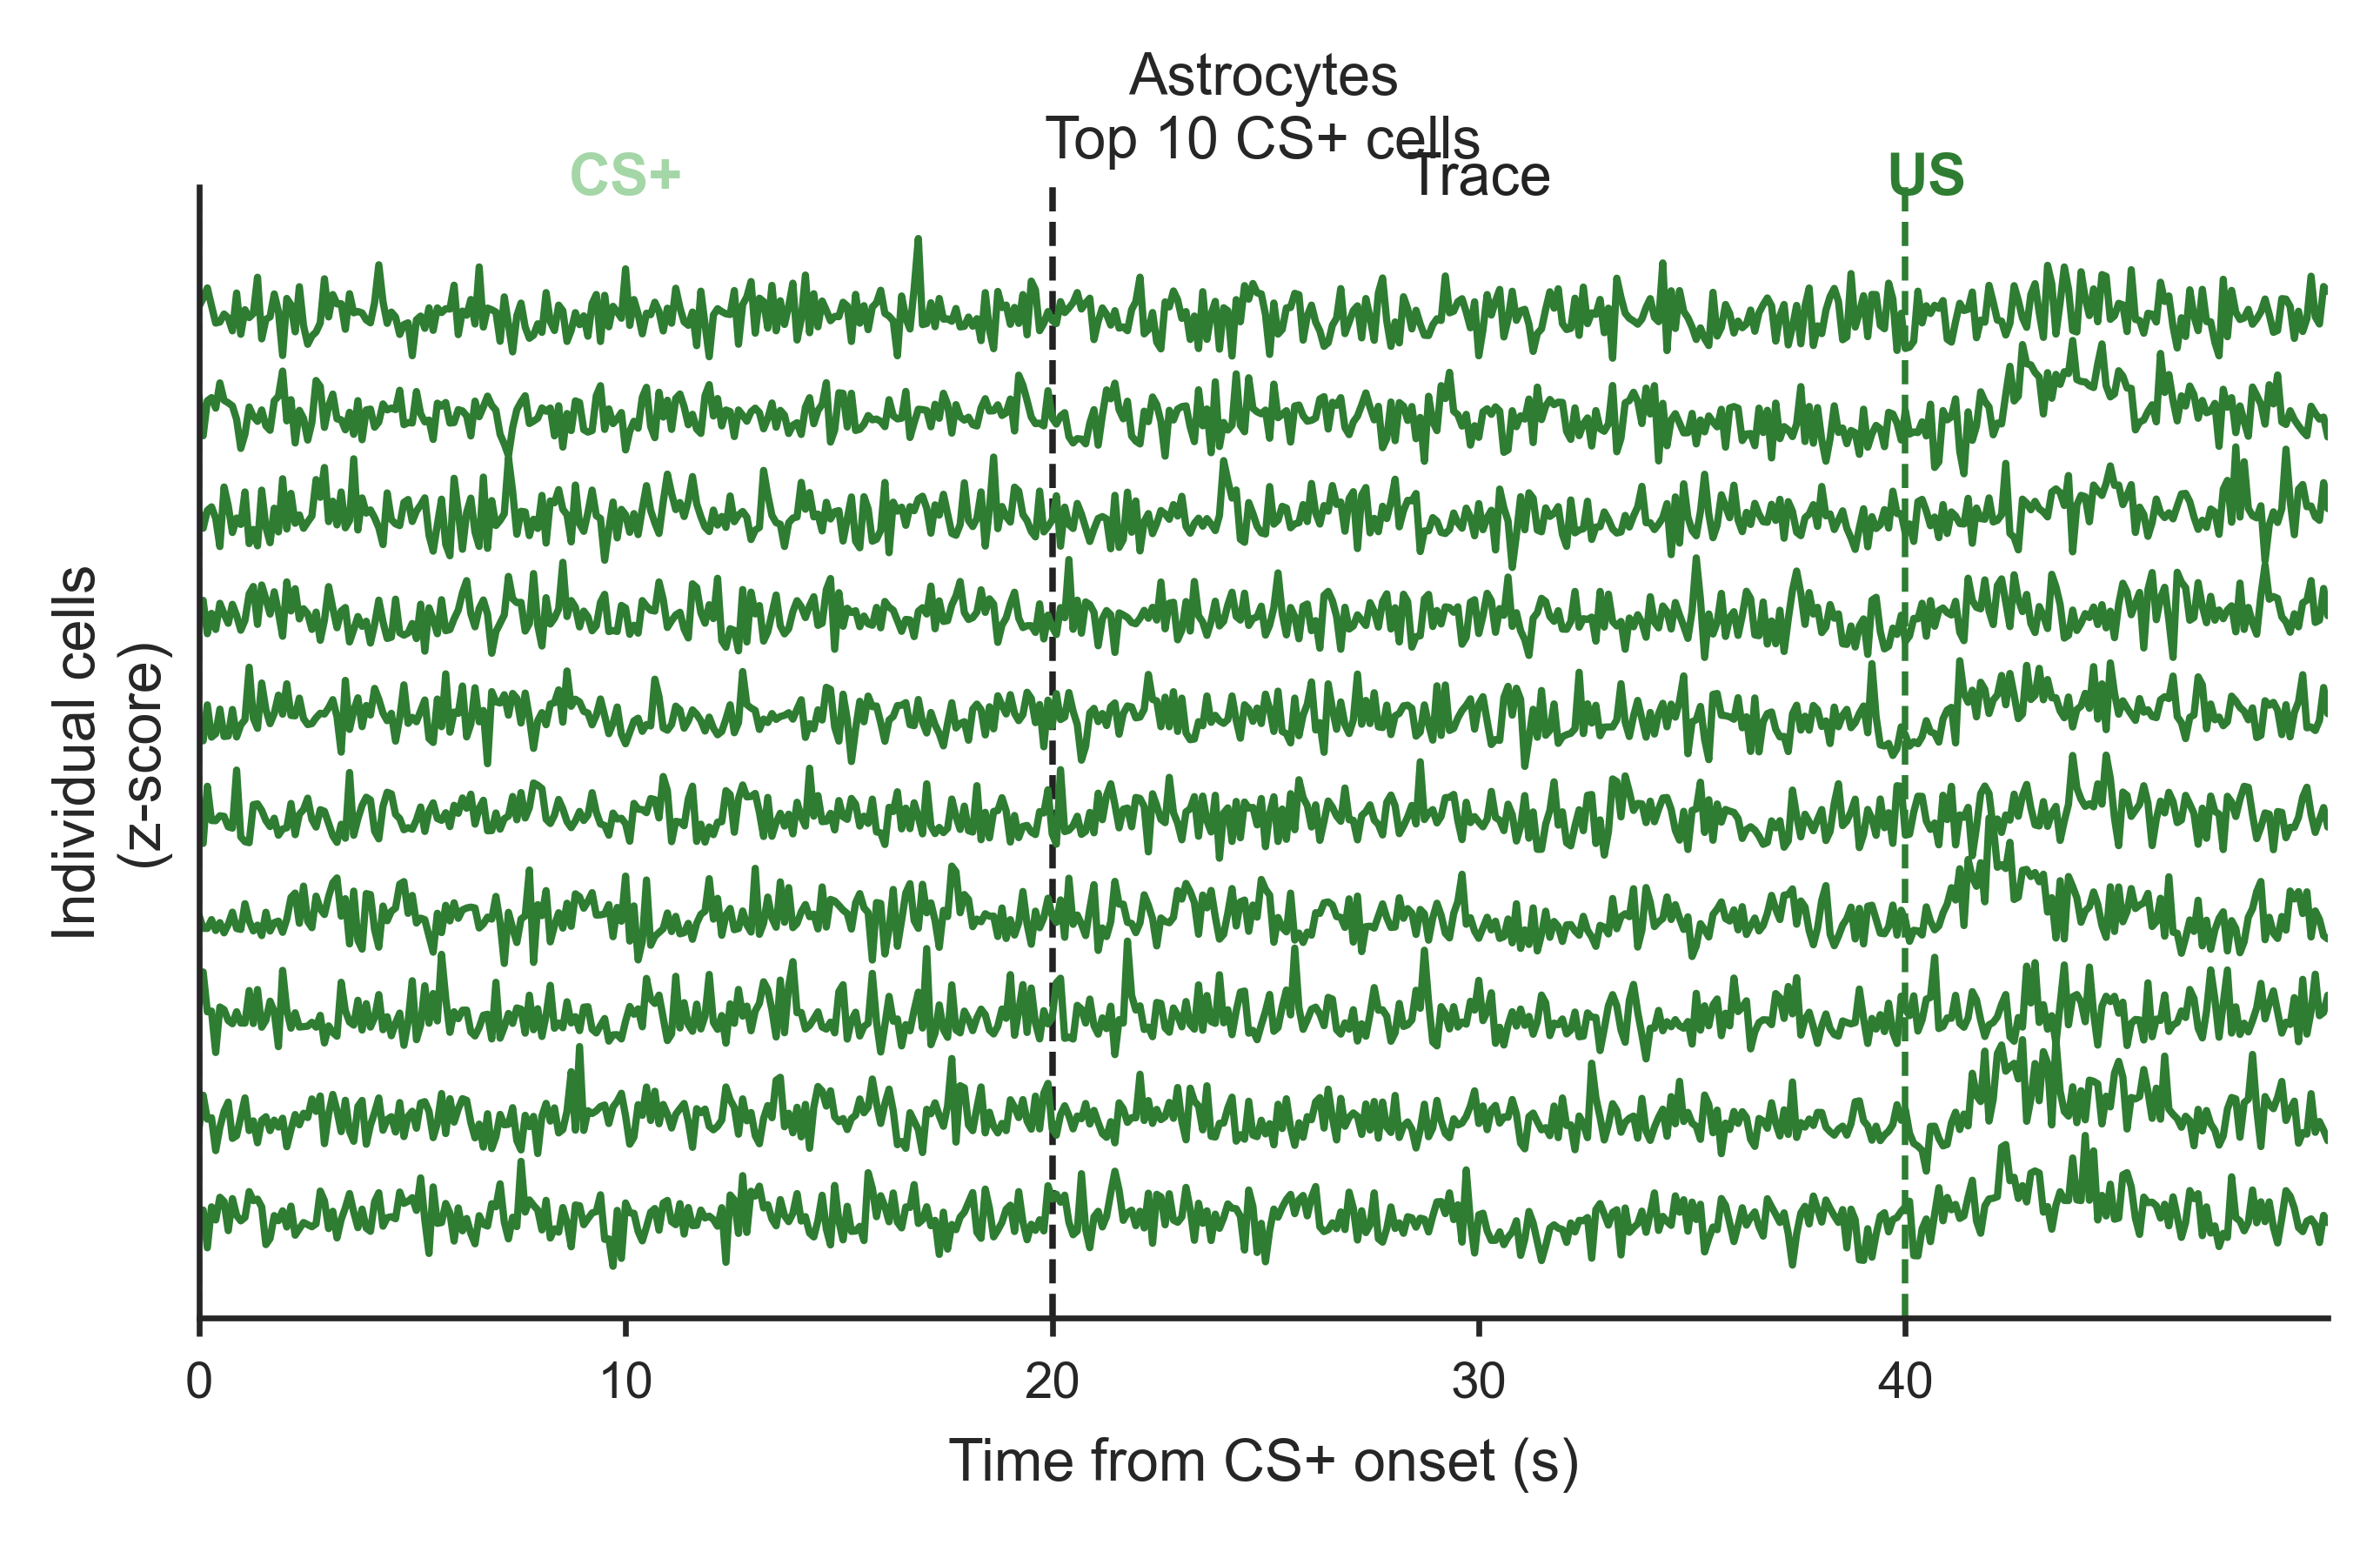

astrocytes top CS+ cells: [11 22 19 14 21 30  1  6 26 20]


In [85]:

for dataset_name, cfg in DATASETS.items():
    fig, ax, cells = plot_stacked_individual_cells(
        result=results[dataset_name],
        cfg=cfg,
        mode="CS+",
        n_cells=10,
        offset_scale=2.5,
        linewidth=1,
        save_base=output_dirs["individual_cells"] / f"{dataset_name}_top10_CS_individual_cells"
    )

    print(dataset_name, "top CS+ cells:", cells)